# 🫀 Pulse AI — 5-Class ACDC Training Notebook
### Cardiac MRI Disease Classification with Threat-Level Mapping
---
**Author:** Abdul Moiz | F22BDOCS1M01076  
**Dataset:** ACDC — Automated Cardiac Diagnosis Challenge (MICCAI 2017)  
**Primary Model Output:** NOR / RV / HCM / MINF / DCM  
**Mapped Output:** Low / Medium / High Threat Level  

---
## 📋 Notebook Flow
```
STEP 1  →  Install Libraries
STEP 2  →  Explore Dataset & Read 5-Class Labels
STEP 3  →  Visualize Raw MRI Slices
STEP 4  →  Convert .nii.gz → PNG Images (optional export / sanity checks)
STEP 5  →  Load Preprocessed HDF5 Slices for Training
STEP 6  →  Build VGG16 5-Class Model
STEP 7  →  Train the Model
STEP 8  →  Evaluate 5-Class Results + Threat Mapping
STEP 9  →  Save Model & Test Single Image Prediction
STEP 10 →  Build Flask API (run separately)
```

### Backbone Note
- This notebook now uses VGG16 for the 5-class disease classifier, following the transfer-learning direction from Untitled1.ipynb.
- Patient-aware splitting, class balancing, and threat mapping are preserved from the 5-class notebook pipeline.

---
## STEP 1 — Install Required Libraries

In [1]:
# Run this cell once to install all dependencies into the active notebook kernel
%pip install nibabel numpy matplotlib opencv-python scikit-learn tensorflow keras seaborn tqdm pillow

print("✅ All libraries installed successfully in the notebook kernel!")
print("ℹ️ If any package was newly installed, restart the kernel once before continuing.")

Note: you may need to restart the kernel to use updated packages.
✅ All libraries installed successfully in the notebook kernel!
ℹ️ If any package was newly installed, restart the kernel once before continuing.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
# ── Import All Libraries ──────────────────────────────────────────
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cv2
import nibabel as nib
import seaborn as sns
from tqdm import tqdm
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import warnings
warnings.filterwarnings('ignore')

print(f"✅ TensorFlow Version : {tf.__version__}")
print(f"✅ NumPy Version      : {np.__version__}")
print(f"✅ All imports done!")

✅ TensorFlow Version : 2.20.0
✅ NumPy Version      : 2.4.2
✅ All imports done!


---
## STEP 2 — Configure Dataset Path & Explore Labels

In [5]:
# ── CONFIGURE DATASET PATHS ───────────────────────────────────────
# Exploration still uses BOTH training (100 patients) and testing (50 patients).
# Model training in Step 5 now uses the local pulse_ai_dataset_5class folder.

DATASET_DIRS       = ['../../Dataset/Resources/training', '../../Dataset/Resources/testing']
OUTPUT_PATH        = '../../Dataset/Resources/pulse_ai_dataset_5class'
TRAINING_DATA_PATH = OUTPUT_PATH
MODEL_PATH         = 'models/pulse_ai_model_5class.h5'
PHASE1_MODEL_PATH  = 'models/best_phase1_5class.h5'
IMAGE_SIZE         = (224, 224)
RANDOM_SEED        = 42
SLICES_PER_FRAME   = 4
ROI_PADDING_RATIO  = 0.18
CENTER_CROP_RATIO  = 0.70

# Use official ACDC class names and normalize any legacy ARV references.
ACDC_CLASSES = ['NOR', 'RV', 'HCM', 'MINF', 'DCM']
ACDC_LABEL_ALIASES = {
    'NOR': 'NOR',
    'RV': 'RV',
    'ARV': 'RV',
    'HCM': 'HCM',
    'MINF': 'MINF',
    'DCM': 'DCM',
}


def normalize_acdc_label(label):
    label = str(label).strip().upper() if label is not None else 'UNKNOWN'
    return ACDC_LABEL_ALIASES.get(label, label)


ACDC_TO_INT = {label: idx for idx, label in enumerate(ACDC_CLASSES)}
INT_TO_ACDC = {idx: label for label, idx in ACDC_TO_INT.items()}
ACDC_TO_NAME = {
    'NOR': 'Normal',
    'RV': 'Abnormal Right Ventricle',
    'HCM': 'Hypertrophic Cardiomyopathy',
    'MINF': 'Myocardial Infarction',
    'DCM': 'Dilated Cardiomyopathy',
}
ACDC_TO_THREAT = {
    'NOR': 'Low',
    'RV': 'Medium',
    'HCM': 'Medium',
    'MINF': 'High',
    'DCM': 'High',
}
THREAT_CLASSES = ['Low', 'Medium', 'High']
THREAT_TO_INT = {label: idx for idx, label in enumerate(THREAT_CLASSES)}
INT_TO_THREAT = {idx: label for label, idx in THREAT_TO_INT.items()}

# Compatibility aliases used by nearby exploration cells.
LABEL_MAP = ACDC_TO_THREAT

print('✅ Configuration set!')
print(f'   Dataset Dirs        : {DATASET_DIRS}')
print(f'   Local Train Source  : {TRAINING_DATA_PATH}')
print(f'   Output Path         : {OUTPUT_PATH}')
print(f'   Model Path          : {MODEL_PATH}')
print(f'   Phase 1 Save Path   : {PHASE1_MODEL_PATH}')
print(f'   Image Size          : {IMAGE_SIZE}')
print(f'   Informative slices  : top {SLICES_PER_FRAME} per frame')
print(f'   ROI padding ratio   : {ROI_PADDING_RATIO}')
print(f'   Fallback crop ratio : {CENTER_CROP_RATIO}')
print('   Training source     : local pulse_ai_dataset_5class + patient-aware split')
print(f'   Total patients expected for exploration: 150 (100 training + 50 testing)')
print()
print('📊 ACDC Label Mapping:')
for acdc in ACDC_CLASSES:
    print(f'   {acdc:4s}  →  {ACDC_TO_NAME[acdc]}  →  Threat: {ACDC_TO_THREAT[acdc]}')
print('   Legacy alias       : ARV → RV')

✅ Configuration set!
   Dataset Dirs        : ['training', 'testing']
   Local Train Source  : pulse_ai_dataset_5class
   Output Path         : pulse_ai_dataset_5class
   Model Path          : pulse_ai_model_5class.h5
   Phase 1 Save Path   : best_phase1_5class.h5
   Image Size          : (224, 224)
   Informative slices  : top 4 per frame
   ROI padding ratio   : 0.18
   Fallback crop ratio : 0.7
   Training source     : local pulse_ai_dataset_5class + patient-aware split
   Total patients expected for exploration: 150 (100 training + 50 testing)

📊 ACDC Label Mapping:
   NOR   →  Normal  →  Threat: Low
   RV    →  Abnormal Right Ventricle  →  Threat: Medium
   HCM   →  Hypertrophic Cardiomyopathy  →  Threat: Medium
   MINF  →  Myocardial Infarction  →  Threat: High
   DCM   →  Dilated Cardiomyopathy  →  Threat: High
   Legacy alias       : ARV → RV


In [6]:
# ── Explore ALL Patients from training + testing folders ──────────
import os  # ensure available even if imports cell was skipped


def read_info(patient_folder):
    """Read Info.cfg and return a dict of patient metadata"""
    info_path = os.path.join(patient_folder, 'Info.cfg')
    info = {}
    with open(info_path, 'r') as f:
        for line in f:
            line = line.strip()
            if ': ' in line:
                key, value = line.split(': ', 1)
                info[key] = value

    raw_group = info.get('Group')
    if raw_group is not None:
        info['RawGroup'] = raw_group
        info['Group'] = normalize_acdc_label(raw_group)
    return info


patient_summary = []
label_counts = {label: 0 for label in ACDC_CLASSES}

for dataset_dir in DATASET_DIRS:
    if not os.path.isdir(dataset_dir):
        print(f"⚠ Directory not found: {dataset_dir}")
        continue

    for patient_id in sorted(os.listdir(dataset_dir)):
        patient_folder = os.path.join(dataset_dir, patient_id)
        if not os.path.isdir(patient_folder):
            continue

        try:
            info = read_info(patient_folder)
            acdc_class = info.get('Group', 'UNKNOWN')
            raw_group = info.get('RawGroup', acdc_class)
            threat = ACDC_TO_THREAT.get(acdc_class, 'Unknown')
            ed = info.get('ED', 'N/A')
            es = info.get('ES', 'N/A')
            label_counts[acdc_class] = label_counts.get(acdc_class, 0) + 1
            patient_summary.append({
                'patient_id': patient_id,
                'source_dir': dataset_dir,
                'acdc_class': acdc_class,
                'group': acdc_class,
                'raw_group': raw_group,
                'threat': threat,
                'ed_frame': ed,
                'es_frame': es,
                'height': info.get('Height', 'N/A'),
                'weight': info.get('Weight', 'N/A')
            })
        except Exception as e:
            print(f"⚠ Could not read {patient_id}: {e}")

print(f"✅ Total patients found: {len(patient_summary)} (from {len(DATASET_DIRS)} folders)")
print()
print("ℹ Canonical labels use official ACDC naming (RV). Legacy ARV is normalized automatically.")
print()
print("📊 Class Distribution (Original ACDC labels):")
for label, count in label_counts.items():
    threat = ACDC_TO_THREAT.get(label, '?')
    bar = '█' * count
    print(f"   {label:4s} ({threat:6s}): {bar} {count}")

threat_counts = {label: 0 for label in THREAT_CLASSES}
for patient in patient_summary:
    threat_counts[patient['threat']] = threat_counts.get(patient['threat'], 0) + 1

print()
print("🎯 Pulse AI Threat Level Distribution:")
for threat, count in threat_counts.items():
    bar = '█' * count
    print(f"   {threat:6s}: {bar} {count}")

✅ Total patients found: 150 (from 2 folders)

ℹ Canonical labels use official ACDC naming (RV). Legacy ARV is normalized automatically.

📊 Class Distribution (Original ACDC labels):
   NOR  (Low   ): ██████████████████████████████ 30
   RV   (Medium): ██████████████████████████████ 30
   HCM  (Medium): ██████████████████████████████ 30
   MINF (High  ): ██████████████████████████████ 30
   DCM  (High  ): ██████████████████████████████ 30

🎯 Pulse AI Threat Level Distribution:
   Low   : ██████████████████████████████ 30
   Medium: ████████████████████████████████████████████████████████████ 60
   High  : ████████████████████████████████████████████████████████████ 60


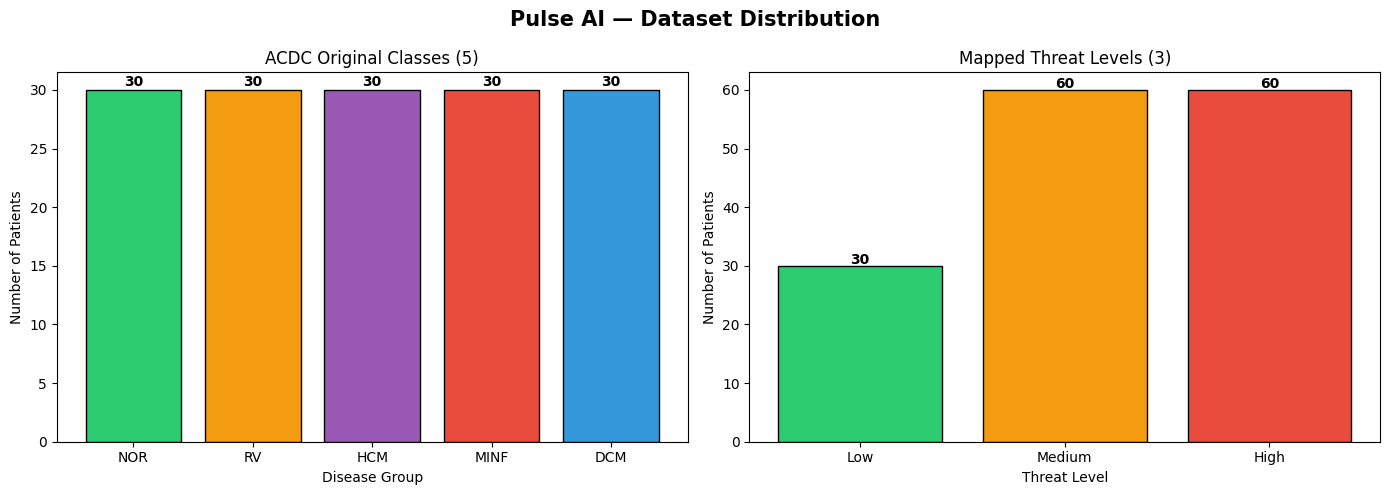

✅ Distribution plot saved!


In [7]:
# ── Plot Class Distribution ───────────────────────────────────────
# Make this cell independent so it still works if the exploration cell was not run.
def _normalize_label_for_plot(label):
    if 'normalize_acdc_label' in globals():
        return normalize_acdc_label(label)
    label = str(label).strip().upper() if label is not None else 'UNKNOWN'
    return {'ARV': 'RV'}.get(label, label)


plot_acdc_classes = []
for label in globals().get('ACDC_CLASSES', ['NOR', 'RV', 'HCM', 'MINF', 'DCM']):
    canonical = _normalize_label_for_plot(label)
    if canonical not in plot_acdc_classes:
        plot_acdc_classes.append(canonical)

if 'label_counts' not in globals() or 'threat_counts' not in globals() or set(label_counts.keys()) != set(plot_acdc_classes):
    def _read_info_for_plot(patient_folder):
        info_path = os.path.join(patient_folder, 'Info.cfg')
        info = {}
        with open(info_path, 'r') as file_obj:
            for line in file_obj:
                line = line.strip()
                if ': ' in line:
                    key, value = line.split(': ', 1)
                    info[key] = value
        raw_group = info.get('Group')
        if raw_group is not None:
            info['Group'] = _normalize_label_for_plot(raw_group)
        return info

    label_counts = {label: 0 for label in plot_acdc_classes}
    threat_counts = {label: 0 for label in THREAT_CLASSES}

    for dataset_dir in DATASET_DIRS:
        if not os.path.isdir(dataset_dir):
            continue
        for patient_id in sorted(os.listdir(dataset_dir)):
            patient_folder = os.path.join(dataset_dir, patient_id)
            if not os.path.isdir(patient_folder):
                continue
            try:
                info = _read_info_for_plot(patient_folder)
                acdc_class = info.get('Group', 'UNKNOWN')
                if acdc_class in label_counts:
                    label_counts[acdc_class] += 1
                    threat_label = ACDC_TO_THREAT.get(acdc_class)
                    if threat_label is not None:
                        threat_counts[threat_label] += 1
            except Exception as exc:
                print(f"⚠ Could not read {patient_id}: {exc}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pulse AI — Dataset Distribution', fontsize=15, fontweight='bold')

colors1 = ['#2ecc71', '#f39c12', '#9b59b6', '#e74c3c', '#3498db']
axes[0].bar(label_counts.keys(), label_counts.values(), color=colors1, edgecolor='black')
axes[0].set_title('ACDC Original Classes (5)', fontsize=12)
axes[0].set_xlabel('Disease Group')
axes[0].set_ylabel('Number of Patients')
for i, (label, count) in enumerate(label_counts.items()):
    axes[0].text(i, count + 0.3, str(count), ha='center', fontweight='bold')

colors2 = ['#2ecc71', '#f39c12', '#e74c3c']
axes[1].bar(threat_counts.keys(), threat_counts.values(), color=colors2, edgecolor='black')
axes[1].set_title('Mapped Threat Levels (3)', fontsize=12)
axes[1].set_xlabel('Threat Level')
axes[1].set_ylabel('Number of Patients')
for i, (threat, count) in enumerate(threat_counts.items()):
    axes[1].text(i, count + 0.3, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('figures/dataset_distribution_5class.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Distribution plot saved!")

---
## STEP 3 — Visualize Raw MRI Slices

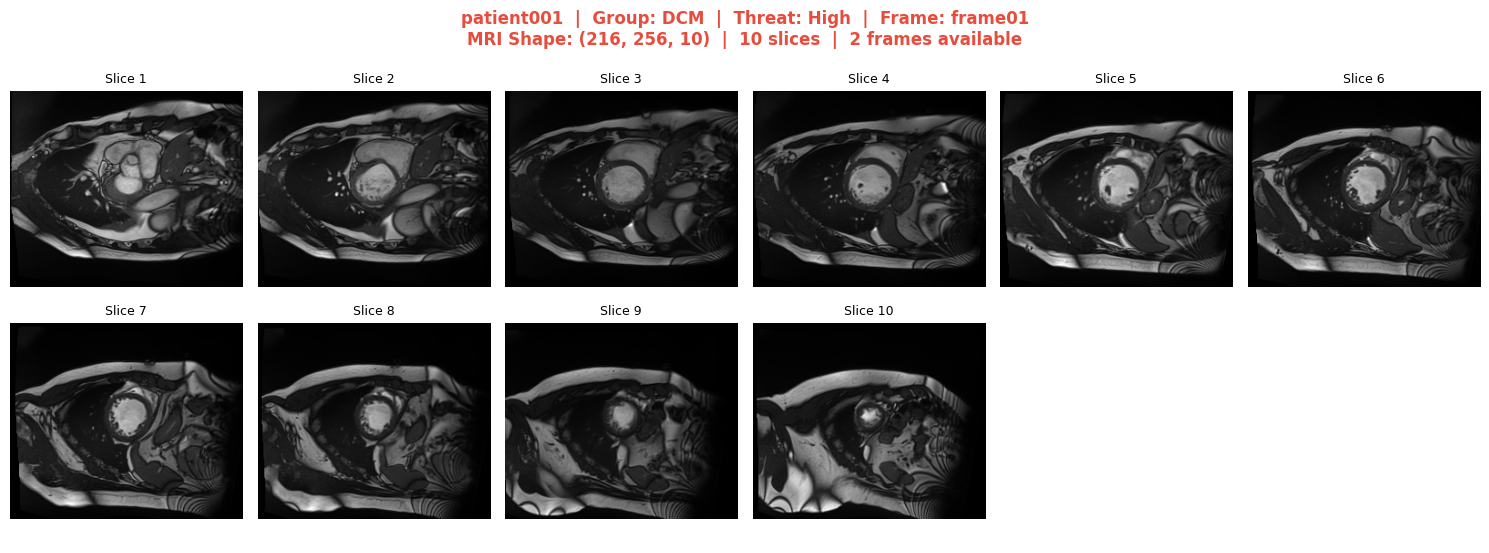

📋 Patient Info: Height=184.0cm, Weight=95.0kg
   Available frames: ['frame01', 'frame12']


In [8]:
# ── Visualize Slices for One Patient ─────────────────────────────
def load_mri_volume(patient_folder, patient_id):
    """Load MRI frames — returns list of (data, frame_name) tuples for ALL available frames"""
    volumes = []
    # Find all frame files (not _gt, not _4d)
    for fname in sorted(os.listdir(patient_folder)):
        if fname.endswith('.nii.gz') and '_frame' in fname and '_gt' not in fname and '_4d' not in fname:
            path = os.path.join(patient_folder, fname)
            img  = nib.load(path)
            data = img.get_fdata()
            # Extract frame name like 'frame01'
            frame = fname.replace(f'{patient_id}_', '').replace('.nii.gz', '')
            volumes.append((data, frame))
    return volumes


def visualize_patient_slices(patient_id, source_dir='training', show_mask=False):
    patient_folder = os.path.join(source_dir, patient_id)
    info = read_info(patient_folder)
    group = info.get('Group', 'UNKNOWN')
    raw_group = info.get('RawGroup', group)
    threat = LABEL_MAP.get(group, 'Unknown')
    group_label = group if raw_group == group else f'{group} (raw: {raw_group})'

    volumes = load_mri_volume(patient_folder, patient_id)
    if not volumes:
        print(f"⚠ No MRI frame found for {patient_id}")
        return

    data, frame = volumes[0]  # Show first frame for visualization

    num_slices = data.shape[2]
    cols = min(num_slices, 6)
    rows = (num_slices + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.8))

    threat_colors = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}
    color = threat_colors.get(threat, 'gray')

    fig.suptitle(
        f'{patient_id}  |  Group: {group_label}  |  Threat: {threat}  |  Frame: {frame}\n'
        f'MRI Shape: {data.shape}  |  {num_slices} slices  |  {len(volumes)} frames available',
        fontsize=12, fontweight='bold', color=color
    )

    axes = np.array(axes).flatten()
    for i in range(len(axes)):
        if i < num_slices:
            axes[i].imshow(data[:, :, i], cmap='gray')
            axes[i].set_title(f'Slice {i+1}', fontsize=9)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()
    print(f"📋 Patient Info: Height={info.get('Height')}cm, Weight={info.get('Weight')}kg")
    print(f"   Available frames: {[v[1] for v in volumes]}")

# ── Show first patient ────────────────────────────────────────────
first = patient_summary[0]
visualize_patient_slices(first['patient_id'], first['source_dir'])

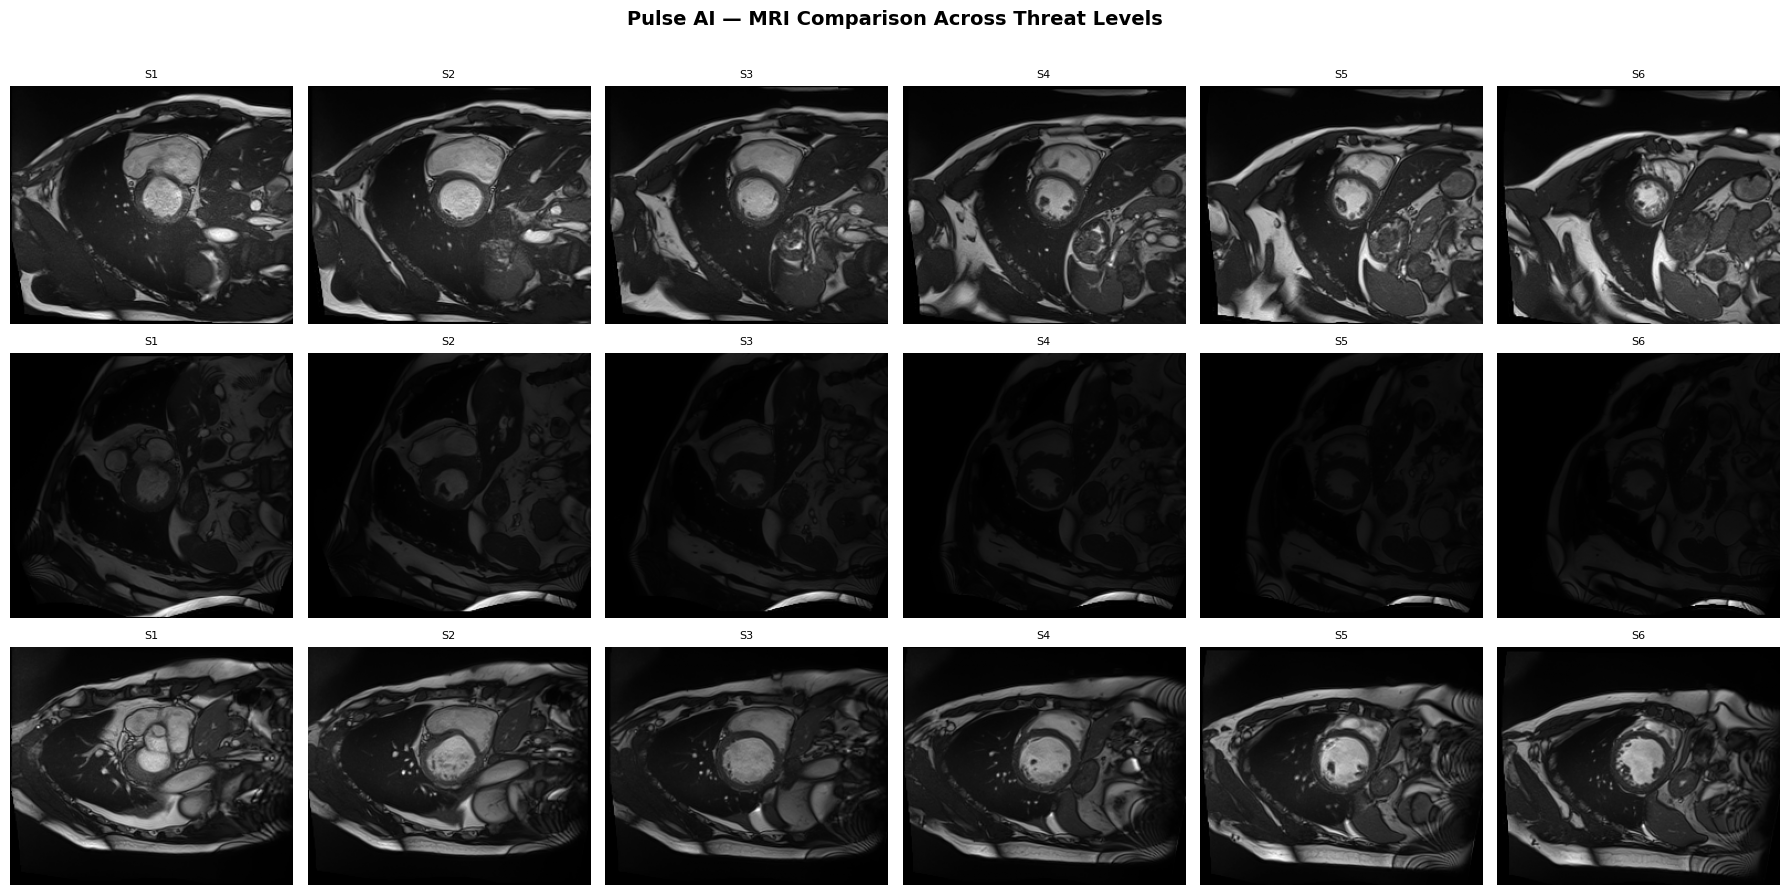

✅ MRI comparison saved!


In [9]:
# ── Compare One Patient from Each Threat Level ───────────────────
ACDC_TO_GROUP = {'Low': 'NOR', 'Medium': 'HCM', 'High': 'DCM'}

fig, big_axes = plt.subplots(3, 6, figsize=(18, 9))
fig.suptitle('Pulse AI — MRI Comparison Across Threat Levels', 
             fontsize=14, fontweight='bold', y=1.01)

row_idx = 0
for threat_level, acdc_group in [('Low (NOR)', 'NOR'), 
                                   ('Medium (HCM)', 'HCM'), 
                                   ('High (DCM)', 'DCM')]:
    sample_patient = next(
        (p for p in patient_summary if p['group'] == acdc_group), None
    )
    
    if sample_patient is None:
        continue
    
    pid    = sample_patient['patient_id']
    folder = os.path.join(sample_patient['source_dir'], pid)
    volumes = load_mri_volume(folder, pid)
    
    threat_colors = {'Low (NOR)': '#2ecc71', 'Medium (HCM)': '#f39c12', 'High (DCM)': '#e74c3c'}
    
    if volumes:
        data = volumes[0][0]
        num_slices = min(data.shape[2], 6)
        for col_idx in range(6):
            ax = big_axes[row_idx][col_idx]
            if col_idx < num_slices:
                ax.imshow(data[:, :, col_idx], cmap='gray')
                ax.set_title(f'S{col_idx+1}', fontsize=8)
            ax.axis('off')
            if col_idx == 0:
                ax.set_ylabel(threat_level, fontsize=10, fontweight='bold',
                              color=threat_colors[threat_level], rotation=90, labelpad=10)
                ax.yaxis.set_visible(True)
    row_idx += 1

plt.tight_layout()
plt.savefig('figures/mri_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ MRI comparison saved!")

---
## STEP 4 — Convert .nii.gz → PNG Images (5 ACDC Classes)

In [10]:
# ── Convert FULL ACDC Dataset to PNG (ROI-cropped, informative slices) ──
import shutil

SLICES_PER_FRAME = globals().get('SLICES_PER_FRAME', 4)
ROI_PADDING_RATIO = globals().get('ROI_PADDING_RATIO', 0.18)
CENTER_CROP_RATIO = globals().get('CENTER_CROP_RATIO', 0.70)


def normalize_slice(slice_2d):
    """Normalize a 2D MRI slice to 0-255 uint8"""
    min_val, max_val = slice_2d.min(), slice_2d.max()
    if max_val == min_val:
        return np.zeros(slice_2d.shape, dtype=np.uint8)
    normalized = (slice_2d - min_val) / (max_val - min_val)
    return (normalized * 255).astype(np.uint8)


def center_crop_slice(slice_2d, crop_ratio=0.70):
    height, width = slice_2d.shape
    crop_h = max(32, int(height * crop_ratio))
    crop_w = max(32, int(width * crop_ratio))
    y0 = max(0, (height - crop_h) // 2)
    x0 = max(0, (width - crop_w) // 2)
    y1 = min(height, y0 + crop_h)
    x1 = min(width, x0 + crop_w)
    return slice_2d[y0:y1, x0:x1]


def crop_to_heart_roi(slice_2d, mask_2d=None, padding_ratio=0.18, fallback_crop_ratio=0.70):
    if mask_2d is None or np.sum(mask_2d > 0) == 0:
        return center_crop_slice(slice_2d, crop_ratio=fallback_crop_ratio)

    coords = np.argwhere(mask_2d > 0)
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0) + 1

    roi_h = max(1, y_max - y_min)
    roi_w = max(1, x_max - x_min)
    pad_y = max(6, int(roi_h * padding_ratio))
    pad_x = max(6, int(roi_w * padding_ratio))

    y0 = max(0, y_min - pad_y)
    y1 = min(slice_2d.shape[0], y_max + pad_y)
    x0 = max(0, x_min - pad_x)
    x1 = min(slice_2d.shape[1], x_max + pad_x)
    return slice_2d[y0:y1, x0:x1]


def load_frame_with_gt(patient_folder, patient_id, frame_num):
    frame_file = os.path.join(patient_folder, f'{patient_id}_frame{frame_num:02d}.nii.gz')
    gt_file = os.path.join(patient_folder, f'{patient_id}_frame{frame_num:02d}_gt.nii.gz')

    if not os.path.exists(frame_file):
        return None, None

    img = nib.load(frame_file)
    data = img.get_fdata()

    gt_data = None
    if os.path.exists(gt_file):
        gt_data = nib.load(gt_file).get_fdata()

    return data, gt_data


def get_informative_slice_indices(gt_data, num_slices, max_slices=4, min_heart_pixels=50):
    if gt_data is not None:
        scored_slices = []
        for slice_idx in range(num_slices):
            heart_pixels = int(np.sum(gt_data[:, :, slice_idx] > 0))
            if heart_pixels >= min_heart_pixels:
                scored_slices.append((slice_idx, heart_pixels))

        if scored_slices:
            top_slices = sorted(scored_slices, key=lambda item: item[1], reverse=True)[:max_slices]
            return sorted(top_slices, key=lambda item: item[0]), len(scored_slices)

    fallback_count = min(max_slices, num_slices)
    start_idx = max(0, (num_slices - fallback_count) // 2)
    fallback = [(slice_idx, 0) for slice_idx in range(start_idx, start_idx + fallback_count)]
    return fallback, len(fallback)


def convert_full_dataset_to_png(patient_list, output_root, img_size=(224, 224)):
    if os.path.exists(output_root):
        shutil.rmtree(output_root)
    for acdc_class in ACDC_CLASSES:
        os.makedirs(os.path.join(output_root, acdc_class), exist_ok=True)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

    stats = {
        'processed': 0,
        'skipped': 0,
        'total_images': 0,
        'total_frames': 0,
        'candidate_slices': 0,
        'discarded_slices': 0,
    }
    for acdc_class in ACDC_CLASSES:
        stats[acdc_class] = 0

    for patient in tqdm(patient_list, desc='Converting ALL patients'):
        pid = patient['patient_id']
        source_dir = patient['source_dir']
        acdc_class = patient['acdc_class']
        ed_frame = int(patient['ed_frame'])
        es_frame = int(patient['es_frame'])
        patient_folder = os.path.join(source_dir, pid)

        if acdc_class not in ACDC_CLASSES:
            stats['skipped'] += 1
            continue

        for frame_num in [ed_frame, es_frame]:
            data, gt_data = load_frame_with_gt(patient_folder, pid, frame_num)
            if data is None:
                continue

            stats['total_frames'] += 1
            num_slices = data.shape[2]
            selected_slices, candidate_count = get_informative_slice_indices(
                gt_data,
                num_slices,
                max_slices=SLICES_PER_FRAME,
                min_heart_pixels=50,
            )
            stats['candidate_slices'] += candidate_count
            stats['discarded_slices'] += max(0, candidate_count - len(selected_slices))

            for slice_idx, heart_pixels in selected_slices:
                mask_slice = gt_data[:, :, slice_idx] if gt_data is not None else None
                slice_2d = data[:, :, slice_idx]
                roi_slice = crop_to_heart_roi(
                    slice_2d,
                    mask_slice,
                    padding_ratio=ROI_PADDING_RATIO,
                    fallback_crop_ratio=CENTER_CROP_RATIO,
                )
                normalized = normalize_slice(roi_slice)
                enhanced = clahe.apply(normalized)
                resized = cv2.resize(enhanced, img_size, interpolation=cv2.INTER_CUBIC)
                rgb = cv2.cvtColor(resized, cv2.COLOR_GRAY2RGB)

                filename = f'{pid}_frame{frame_num:02d}_slice{slice_idx:02d}_area{heart_pixels:05d}.png'
                out_path = os.path.join(output_root, acdc_class, filename)
                cv2.imwrite(out_path, rgb)

                stats['total_images'] += 1
                stats[acdc_class] += 1

        stats['processed'] += 1

    return stats


print("🔄 Starting ROI-focused 5-class dataset conversion...")
print(f"   Patients        : {len(patient_summary)} (training + testing)")
print(f"   Frames/patient  : 2 (ED + ES from Info.cfg)")
print(f"   Slice ranking   : top {SLICES_PER_FRAME} slices/frame by GT heart area")
print(f"   ROI crop        : heart bounding box + {ROI_PADDING_RATIO:.0%} padding")
print(f"   Fallback crop   : center {CENTER_CROP_RATIO:.0%} of the image")
print(f"   Enhancement     : CLAHE contrast boost")
print(f"   Output          : {OUTPUT_PATH}")
print()

stats = convert_full_dataset_to_png(patient_summary, OUTPUT_PATH, IMAGE_SIZE)

print()
print("✅ ROI-focused 5-class conversion complete!")
print(f"   Patients processed  : {stats['processed']}")
print(f"   Patients skipped    : {stats['skipped']}")
print(f"   Total frames used   : {stats['total_frames']}")
print(f"   Candidate slices    : {stats['candidate_slices']}")
print(f"   Discarded slices    : {stats['discarded_slices']}")
print(f"   Total PNG images    : {stats['total_images']}")
print()
print("📊 Images per ACDC class:")
for acdc_class in ACDC_CLASSES:
    print(f"   {acdc_class:4s} : {stats[acdc_class]} images")

🔄 Starting ROI-focused 5-class dataset conversion...
   Patients        : 150 (training + testing)
   Frames/patient  : 2 (ED + ES from Info.cfg)
   Slice ranking   : top 4 slices/frame by GT heart area
   ROI crop        : heart bounding box + 18% padding
   Fallback crop   : center 70% of the image
   Enhancement     : CLAHE contrast boost
   Output          : pulse_ai_dataset_5class



Converting ALL patients: 100%|██████████| 150/150 [00:29<00:00,  5.09it/s]


✅ ROI-focused 5-class conversion complete!
   Patients processed  : 150
   Patients skipped    : 0
   Total frames used   : 300
   Candidate slices    : 2837
   Discarded slices    : 1637
   Total PNG images    : 1200

📊 Images per ACDC class:
   NOR  : 240 images
   RV   : 240 images
   HCM  : 240 images
   MINF : 240 images
   DCM  : 240 images


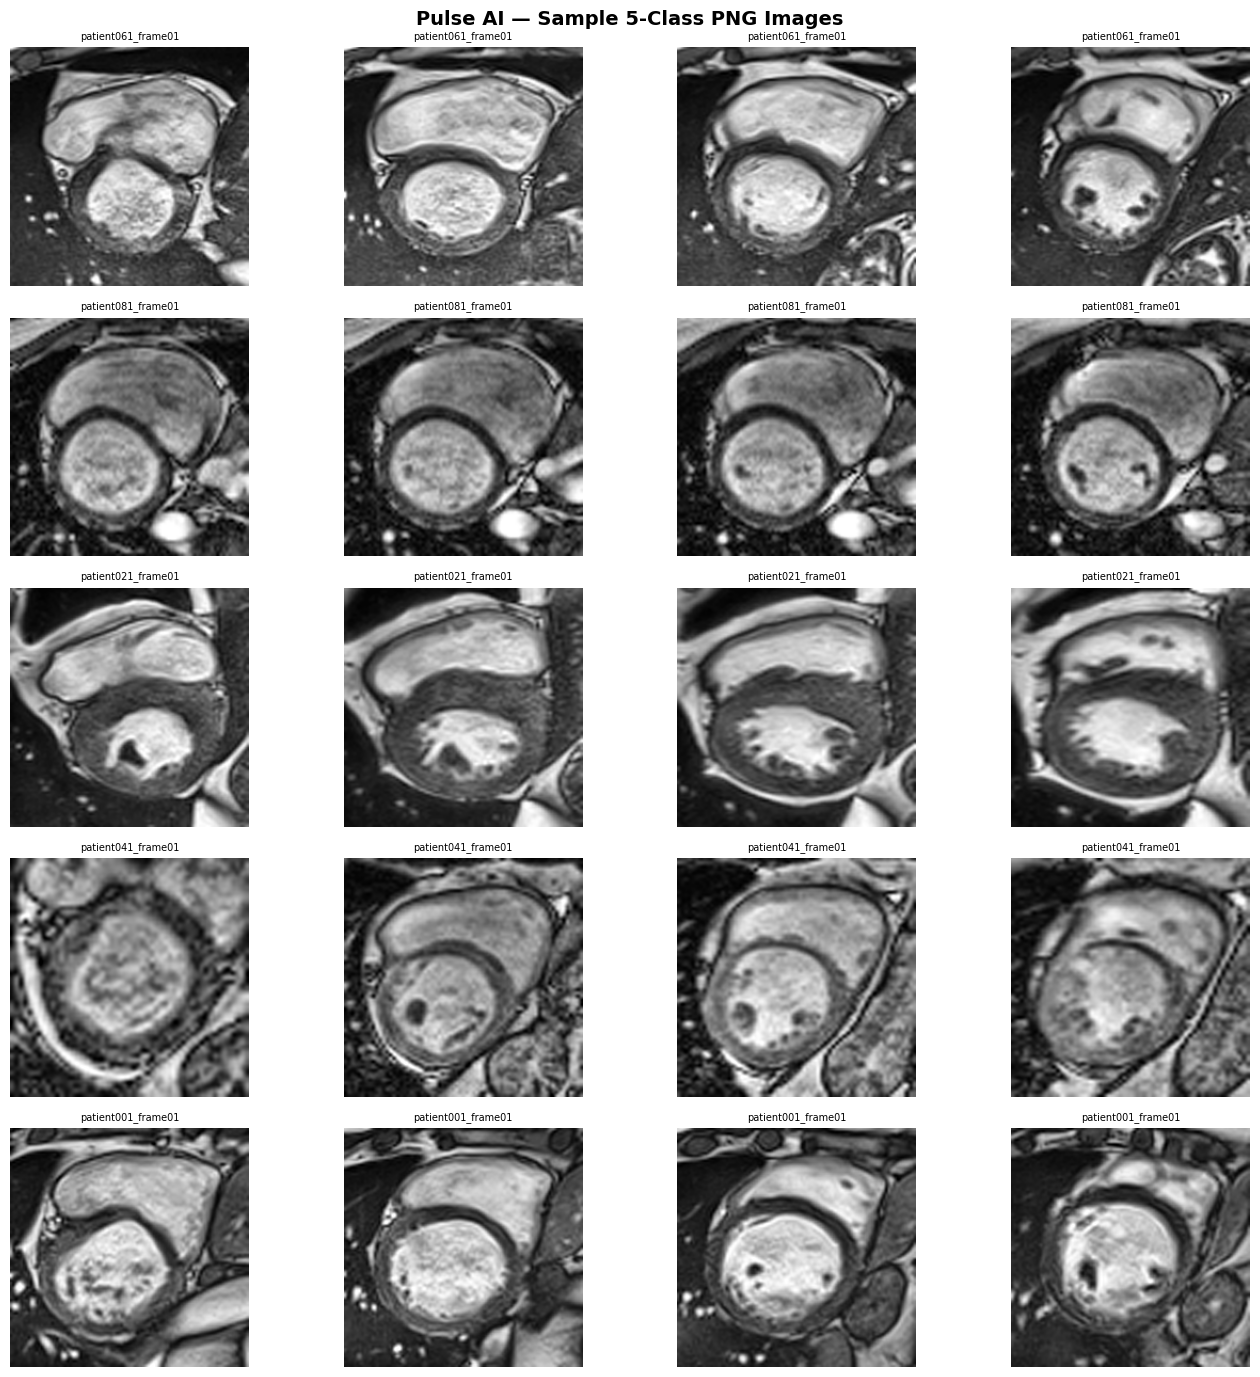

✅ PNG samples verified!


In [11]:
# ── Verify PNG Output — Show Sample Images ────────────────────────
fig, axes = plt.subplots(5, 4, figsize=(14, 14))
fig.suptitle('Pulse AI — Sample 5-Class PNG Images', fontsize=14, fontweight='bold')

class_colors = {
    'NOR': '#2ecc71',
    'RV': '#f39c12',
    'HCM': '#9b59b6',
    'MINF': '#e74c3c',
    'DCM': '#3498db',
}

for row, acdc_class in enumerate(ACDC_CLASSES):
    folder = os.path.join(OUTPUT_PATH, acdc_class)
    images = sorted(os.listdir(folder))[:4]

    for col, fname in enumerate(images):
        img = cv2.imread(os.path.join(folder, fname))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[row][col].imshow(img)
        axes[row][col].set_title(fname.split('_slice')[0], fontsize=7)
        axes[row][col].axis('off')

    axes[row][0].set_ylabel(
        f'{acdc_class} ({ACDC_TO_THREAT[acdc_class]})',
        fontsize=10,
        fontweight='bold',
        color=class_colors.get(acdc_class, 'gray'),
    )
    axes[row][0].yaxis.set_visible(True)

plt.tight_layout()
plt.savefig('figures/sample_png_output_5class.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ PNG samples verified!")

---
## STEP 5 — Load 5-Class Data from Local pulse_ai_dataset_5class Folder

Training now uses the local `pulse_ai_dataset_5class` directory in this workspace instead of Google Drive paths. The loader reads class-organized PNG images, keeps patient ids, and preserves the patient-aware split used by the 5-class pipeline.

In [12]:
# ── Load Local pulse_ai_dataset_5class Images into Memory ──────────


def extract_patient_id(filename):
    """Extract patient id from a PNG name like patient001_frame01_slice07.png"""
    return filename.split('_frame')[0]


def load_all_images(data_root, img_size=(224, 224)):
    X, y, patient_ids = [], [], []
    patient_label_map = {}

    if not os.path.isdir(data_root):
        raise FileNotFoundError(f'Local dataset folder not found: {data_root}')

    for acdc_class, label_int in ACDC_TO_INT.items():
        folder = os.path.join(data_root, acdc_class)
        if not os.path.isdir(folder):
            raise FileNotFoundError(f'Missing class folder: {folder}')

        files = sorted(fname for fname in os.listdir(folder) if fname.endswith('.png'))
        for fname in tqdm(files, desc=f'Loading {acdc_class}'):
            path = os.path.join(folder, fname)
            img = cv2.imread(path, cv2.IMREAD_COLOR)
            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, img_size, interpolation=cv2.INTER_CUBIC)

            patient_id = extract_patient_id(fname)
            X.append(img.astype(np.float32))
            y.append(label_int)
            patient_ids.append(patient_id)
            patient_label_map[patient_id] = label_int

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int32)
    patient_ids = np.array(patient_ids)
    return X, y, patient_ids, patient_label_map


print('🔄 Loading local pulse_ai_dataset_5class images into memory...')
X, y, patient_ids, patient_label_map = load_all_images(TRAINING_DATA_PATH, IMAGE_SIZE)

print(f'\n✅ Dataset loaded from local folder!')
print(f'   Source path        : {TRAINING_DATA_PATH}')
print(f'   X shape            : {X.shape}')
print(f'   y shape            : {y.shape}')
print(f'   Unique patients    : {len(patient_label_map)}')
print(f'   Pixel range        : min={X.min():.1f}, max={X.max():.1f}')
print(f'   Input scale        : 0-255 RGB images from local PNG dataset')
print(f'   Memory usage       : {X.nbytes / 1024**2:.1f} MB')
print()
print('📊 ACDC class distribution:')
for acdc_class, label_int in ACDC_TO_INT.items():
    print(f'   {acdc_class:4s} : {np.sum(y == label_int)}')

🔄 Loading local pulse_ai_dataset_5class images into memory...


Loading DCM: 100%|██████████| 240/240 [00:02<00:00, 107.36it/s]



✅ Dataset loaded from local folder!
   Source path        : pulse_ai_dataset_5class
   X shape            : (1200, 224, 224, 3)
   y shape            : (1200,)
   Unique patients    : 150
   Pixel range        : min=0.0, max=255.0
   Input scale        : 0-255 RGB images from local PNG dataset
   Memory usage       : 689.1 MB

📊 ACDC class distribution:
   NOR  : 240
   RV   : 240
   HCM  : 240
   MINF : 240
   DCM  : 240


In [13]:
# ── Train / Validation / Test Split ──────────────────────────────
# 70% Train | 15% Validation | 15% Test
# Split by patient_id so slices from the same patient never leak across sets.

unique_patients = np.array(sorted(patient_label_map.keys()))
patient_labels = np.array([patient_label_map[pid] for pid in unique_patients])

train_patients, temp_patients, y_train_patients, y_temp_patients = train_test_split(
    unique_patients,
    patient_labels,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=patient_labels,
)
val_patients, test_patients, y_val_patients, y_test_patients = train_test_split(
    temp_patients,
    y_temp_patients,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=y_temp_patients,
)

train_mask = np.isin(patient_ids, train_patients)
val_mask = np.isin(patient_ids, val_patients)
test_mask = np.isin(patient_ids, test_patients)

train_patient_ids = patient_ids[train_mask]
val_patient_ids = patient_ids[val_mask]
test_patient_ids = patient_ids[test_mask]

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

y_train_cat = to_categorical(y_train, num_classes=len(ACDC_CLASSES))
y_val_cat = to_categorical(y_val, num_classes=len(ACDC_CLASSES))
y_test_cat = to_categorical(y_test, num_classes=len(ACDC_CLASSES))

train_val_overlap = set(train_patients) & set(val_patients)
train_test_overlap = set(train_patients) & set(test_patients)
val_test_overlap = set(val_patients) & set(test_patients)

print("✅ Patient-level split complete:")
print(f"   Train patients : {len(train_patients)}")
print(f"   Val patients   : {len(val_patients)}")
print(f"   Test patients  : {len(test_patients)}")
print(f"   Train images   : {X_train.shape[0]}")
print(f"   Validation imgs: {X_val.shape[0]}")
print(f"   Test images    : {X_test.shape[0]}")
print(f"   Leakage check  : {len(train_val_overlap) + len(train_test_overlap) + len(val_test_overlap)} shared patients")

classes = np.unique(y_train)
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train,
)
class_weights = {int(cls): float(weight) for cls, weight in zip(classes, class_weights_arr)}

train_unique_ids, train_slice_counts = np.unique(train_patient_ids, return_counts=True)
train_patient_slice_counts = {pid: int(count) for pid, count in zip(train_unique_ids, train_slice_counts)}
train_sample_weights = np.array([
    class_weights[int(label)] / train_patient_slice_counts[patient_id]
    for patient_id, label in zip(train_patient_ids, y_train)
], dtype=np.float32)
train_sample_weights *= len(train_sample_weights) / np.sum(train_sample_weights)

print(f"\n📊 5-Class Weights: {class_weights}")
print(f"   Max train slices/patient : {max(train_patient_slice_counts.values())}")
print(f"   Mean sample weight       : {train_sample_weights.mean():.2f}")
print(f"   Weight range             : {train_sample_weights.min():.2f} → {train_sample_weights.max():.2f}")

✅ Patient-level split complete:
   Train patients : 105
   Val patients   : 22
   Test patients  : 23
   Train images   : 840
   Validation imgs: 176
   Test images    : 184
   Leakage check  : 0 shared patients

📊 5-Class Weights: {0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0}
   Max train slices/patient : 8
   Mean sample weight       : 1.00
   Weight range             : 1.00 → 1.00


✅ Data augmentation pipeline ready!
   Batch size       : 16
   Steps per epoch  : 53
   Input scale      : raw 0-255 → VGG16 preprocess_input
   Augmentation     : mild geometry + mild brightness
   Rebalancing      : inverse 5-class frequency × inverse slices/patient


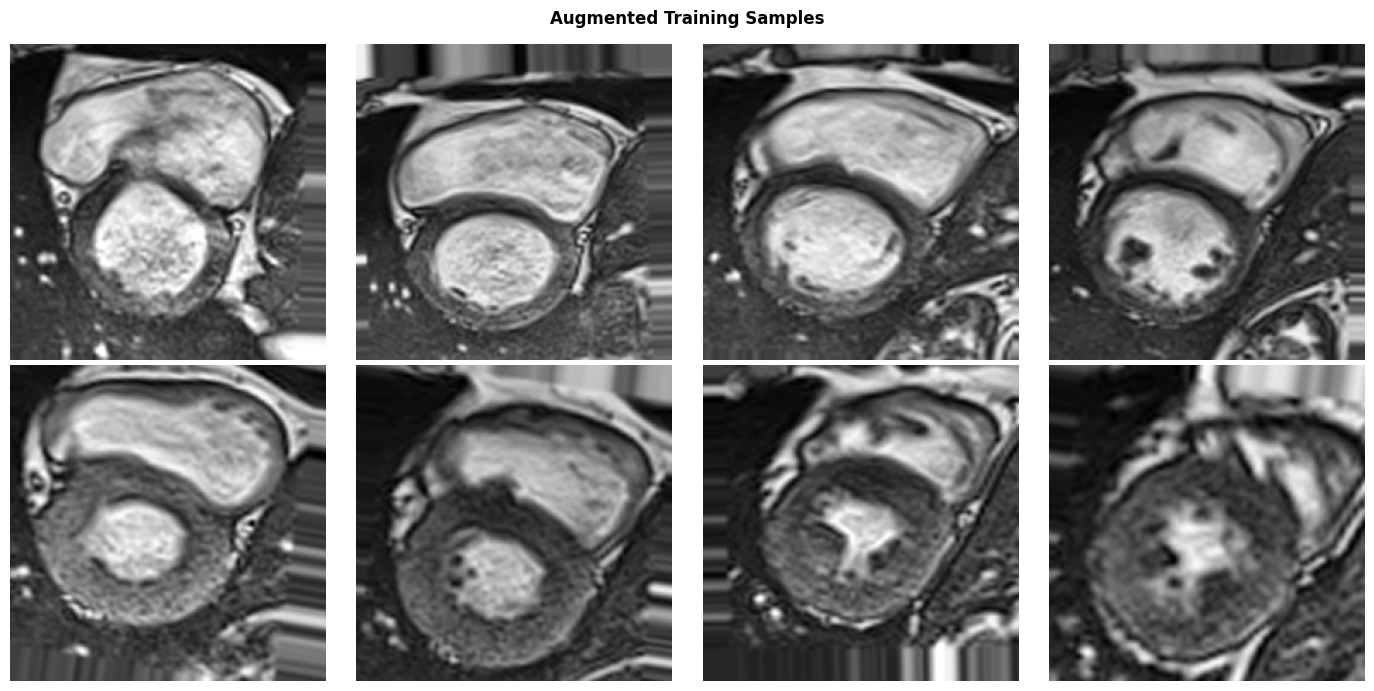

In [14]:
# ── Data Augmentation Pipeline ────────────────────────────────────
# VGG16 uses ImageNet preprocessing, so generators convert raw 0-255 RGB
# images into the correct input space during training/validation/testing.

from tensorflow.keras.applications.vgg16 import preprocess_input


def to_display_image(image):
    image = np.asarray(image, dtype=np.float32)
    if image.max() <= 1.5:
        image = image * 255.0
    image = np.clip(image, 0, 255)
    return image.astype(np.uint8)


augment_kwargs = dict(
    rotation_range=10,
    width_shift_range=0.06,
    height_shift_range=0.06,
    zoom_range=0.10,
    brightness_range=[0.92, 1.08],
    horizontal_flip=False,
    vertical_flip=False,
    fill_mode='nearest',
)

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    **augment_kwargs,
)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
BATCH_SIZE = 16

train_gen = train_datagen.flow(
    X_train,
    y_train_cat,
    sample_weight=train_sample_weights,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=RANDOM_SEED,
)
val_gen = val_datagen.flow(
    X_val,
    y_val_cat,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print("✅ Data augmentation pipeline ready!")
print(f"   Batch size       : {BATCH_SIZE}")
print(f"   Steps per epoch  : {len(train_gen)}")
print(f"   Input scale      : raw 0-255 → VGG16 preprocess_input")
print(f"   Augmentation     : mild geometry + mild brightness")
print(f"   Rebalancing      : inverse 5-class frequency × inverse slices/patient")

preview_datagen = ImageDataGenerator(**augment_kwargs)
preview_gen = preview_datagen.flow(
    X_train[:8],
    y_train_cat[:8],
    batch_size=8,
    shuffle=False,
    seed=RANDOM_SEED,
)
sample_batch, _ = next(preview_gen)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
fig.suptitle('Augmented Training Samples', fontsize=12, fontweight='bold')
for i, ax in enumerate(axes.flatten()):
    if i < len(sample_batch):
        ax.imshow(to_display_image(sample_batch[i]))
    ax.axis('off')
plt.tight_layout()
plt.show()

---
## STEP 6 — Build VGG16 5-Class Classification Model

In [15]:
# ── Build VGG16-Based Pulse AI 5-Class Model ───────────────────────
from tensorflow.keras.applications import VGG16


def build_pulse_ai_model(input_shape=(224, 224, 3), num_classes=5):
    """
    VGG16 + the reference classification head from Untitled1.ipynb, adapted to
    the patient-aware 5-class training pipeline in this notebook.
    """
    base_model = VGG16(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet',
    )
    base_model.trainable = False

    inputs = keras.Input(shape=input_shape)
    features = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D(name='global_avg_pool')(features)
    x = layers.Dense(256, activation='relu', name='dense_256')(x)
    x = layers.Dropout(0.50, name='dropout_1')(x)
    x = layers.Dense(128, activation='relu', name='dense_128')(x)
    x = layers.Dropout(0.30, name='dropout_2')(x)
    outputs = layers.Dense(
        num_classes,
        activation='softmax',
        name='acdc_prediction',
    )(x)

    model = keras.Model(inputs, outputs, name='PulseAI_VGG16_5Class')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')],
    )
    return model, base_model


print("🔄 Building VGG16-based 5-class model...")
model, base_model = build_pulse_ai_model(input_shape=(*IMAGE_SIZE, 3), num_classes=len(ACDC_CLASSES))

print("\n🧠 Pulse AI Model Architecture:")
print("   Base model       : VGG16 (ImageNet pretrained)")
print(f"   Input shape      : {IMAGE_SIZE + (3,)}")
print(f"   Primary output   : {len(ACDC_CLASSES)} ACDC classes")
print(f"   Mapped output    : 3 threat levels after inference")
print("   Preprocessing    : VGG16 preprocess_input in generators/inference")
print("   Head             : GAP → 256 → 128 → 5")
print()
model.summary()

🔄 Building VGG16-based 5-class model...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 16s 0us/step

🧠 Pulse AI Model Architecture:
   Base model       : VGG16 (ImageNet pretrained)
   Input shape      : (224, 224, 3)
   Primary output   : 5 ACDC classes
   Mapped output    : 3 threat levels after inference
   Preprocessing    : VGG16 preprocess_input in generators/inference
   Head             : GAP → 256 → 128 → 5



Model: "PulseAI_VGG16_5Class"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ acdc_prediction (Dense)         │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,879,557 (56.76 MB)

 Trainable params: 164,869 (644.02 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

---
## STEP 7 — Train the 5-Class Model (Two Phases)

In [16]:
# ── PHASE 1: Train Custom Head (Base Frozen) ──────────────────────

callbacks_phase1 = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=8,
        restore_best_weights=True,
        mode='max',
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
    ModelCheckpoint(
        PHASE1_MODEL_PATH,
        save_best_only=True,
        monitor='val_accuracy',
        mode='max',
        verbose=1,
    ),
]

print("🚀 PHASE 1 Training — VGG16 Head Only (Base Frozen)")
print(f"   Epochs     : up to 25")
print(f"   Batch size : {BATCH_SIZE}")
print(f"   LR         : 1e-4")
print(f"   Sampling   : patient-aware weighted batches")
print()

history1 = model.fit(
    train_gen,
    epochs=25,
    validation_data=val_gen,
    callbacks=callbacks_phase1,
    verbose=1,
)

phase1_acc = max(history1.history['val_accuracy'])
print(f"\n✅ Phase 1 Complete! Best Val Accuracy: {phase1_acc:.4f} ({phase1_acc*100:.2f}%)")

🚀 PHASE 1 Training — VGG16 Head Only (Base Frozen)
   Epochs     : up to 25
   Batch size : 16
   LR         : 1e-4
   Sampling   : patient-aware weighted batches

Epoch 1/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.1810 - auc: 0.4918 - loss: 6.2683
Epoch 1: val_accuracy improved from None to 0.18750, saving model to best_phase1_5class.h5



Epoch 1: finished saving model to best_phase1_5class.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 234s 4s/step - accuracy: 0.1750 - auc: 0.4780 - loss: 5.6237 - val_accuracy: 0.1875 - val_auc: 0.5324 - val_loss: 2.2617 - learning_rate: 1.0000e-04
Epoch 2/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.2226 - auc: 0.5203 - loss: 3.9019
Epoch 2: val_accuracy improved from 0.18750 to 0.23295, saving model to best_phase1_5class.h5



Epoch 2: finished saving model to best_phase1_5class.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 262s 5s/step - accuracy: 0.2214 - auc: 0.5186 - loss: 3.7478 - val_accuracy: 0.2330 - val_auc: 0.5734 - val_loss: 1.8632 - learning_rate: 1.0000e-04
Epoch 3/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.2405 - auc: 0.5521 - loss: 2.9891
Epoch 3: val_accuracy improved from 0.23295 to 0.27273, saving model to best_phase1_5class.h5



Epoch 3: finished saving model to best_phase1_5class.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 259s 5s/step - accuracy: 0.2488 - auc: 0.5676 - loss: 2.8034 - val_accuracy: 0.2727 - val_auc: 0.5929 - val_loss: 1.7177 - learning_rate: 1.0000e-04
Epoch 4/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.2629 - auc: 0.5645 - loss: 2.6313
Epoch 4: val_accuracy improved from 0.27273 to 0.28409, saving model to best_phase1_5class.h5



Epoch 4: finished saving model to best_phase1_5class.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 244s 5s/step - accuracy: 0.2619 - auc: 0.5728 - loss: 2.5082 - val_accuracy: 0.2841 - val_auc: 0.6080 - val_loss: 1.6451 - learning_rate: 1.0000e-04
Epoch 5/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.2535 - auc: 0.5749 - loss: 2.3649
Epoch 5: val_accuracy improved from 0.28409 to 0.34091, saving model to best_phase1_5class.h5


...


Epoch 17: finished saving model to best_phase1_5class.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 256s 5s/step - accuracy: 0.3905 - auc: 0.7169 - loss: 1.4414 - val_accuracy: 0.4432 - val_auc: 0.7221 - val_loss: 1.4057 - learning_rate: 1.0000e-04
Epoch 18/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4403 - auc: 0.7401 - loss: 1.4023
Epoch 18: val_accuracy improved from 0.44318 to 0.44886, saving model to best_phase1_5class.h5



Epoch 18: finished saving model to best_phase1_5class.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 240s 5s/step - accuracy: 0.4357 - auc: 0.7444 - loss: 1.3786 - val_accuracy: 0.4489 - val_auc: 0.7250 - val_loss: 1.3940 - learning_rate: 1.0000e-04
Epoch 19/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4134 - auc: 0.7247 - loss: 1.4253
Epoch 19: val_accuracy did not improve from 0.44886
53/53 ━━━━━━━━━━━━━━━━━━━━ 240s 5s/step - accuracy: 0.4238 - auc: 0.7286 - loss: 1.4127 - val_accuracy: 0.4375 - val_auc: 0.7181 - val_loss: 1.4065 - learning_rate: 1.0000e-04
Epoch 20/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.3627 - auc: 0.7198 - loss: 1.4302
Epoch 20: val_accuracy improved from 0.44886 to 0.46591, saving model to best_phase1_5class.h5



Epoch 20: finished saving model to best_phase1_5class.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 233s 4s/step - accuracy: 0.3940 - auc: 0.7188 - loss: 1.4424 - val_accuracy: 0.4659 - val_auc: 0.7527 - val_loss: 1.3527 - learning_rate: 1.0000e-04
Epoch 21/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4008 - auc: 0.7376 - loss: 1.3836
Epoch 21: val_accuracy did not improve from 0.46591
53/53 ━━━━━━━━━━━━━━━━━━━━ 232s 4s/step - accuracy: 0.4024 - auc: 0.7381 - loss: 1.3825 - val_accuracy: 0.4489 - val_auc: 0.7544 - val_loss: 1.3454 - learning_rate: 1.0000e-04
Epoch 22/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4542 - auc: 0.7633 - loss: 1.3186
Epoch 22: val_accuracy improved from 0.46591 to 0.47159, saving model to best_phase1_5class.h5



Epoch 22: finished saving model to best_phase1_5class.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 259s 4s/step - accuracy: 0.4452 - auc: 0.7624 - loss: 1.3222 - val_accuracy: 0.4716 - val_auc: 0.7601 - val_loss: 1.3273 - learning_rate: 1.0000e-04
Epoch 23/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4384 - auc: 0.7459 - loss: 1.3949
Epoch 23: val_accuracy did not improve from 0.47159
53/53 ━━━━━━━━━━━━━━━━━━━━ 227s 4s/step - accuracy: 0.4464 - auc: 0.7557 - loss: 1.3550 - val_accuracy: 0.4659 - val_auc: 0.7646 - val_loss: 1.3236 - learning_rate: 1.0000e-04
Epoch 24/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4309 - auc: 0.7490 - loss: 1.3502
Epoch 24: val_accuracy did not improve from 0.47159
53/53 ━━━━━━━━━━━━━━━━━━━━ 266s 4s/step - accuracy: 0.4417 - auc: 0.7572 - loss: 1.3322 - val_accuracy: 0.4545 - val_auc: 0.7650 - val_loss: 1.3163 - learning_rate: 1.0000e-04
Epoch 25/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4526 - auc: 0.7682 - loss: 1.3216
Epoch 25: val_ac


Epoch 25: finished saving model to best_phase1_5class.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 263s 4s/step - accuracy: 0.4631 - auc: 0.7683 - loss: 1.3193 - val_accuracy: 0.4830 - val_auc: 0.7707 - val_loss: 1.3070 - learning_rate: 1.0000e-04
Restoring model weights from the end of the best epoch: 25.

✅ Phase 1 Complete! Best Val Accuracy: 0.4830 (48.30%)


In [17]:
# ── PHASE 2: Fine-tune Top VGG16 Layers ───────────────────────────
print("🔧 PHASE 2 — Fine-tuning VGG16")
print()

base_model.trainable = True
fine_tune_from = 'block5_conv1'
set_trainable = False

for layer in base_model.layers:
    if layer.name == fine_tune_from:
        set_trainable = True
    layer.trainable = set_trainable

trainable_layers = [layer.name for layer in base_model.layers if layer.trainable]
print(f"   Fine-tune from   : {fine_tune_from}")
print(f"   Trainable layers : {len(trainable_layers)}")
print(f"   Last layers      : {', '.join(trainable_layers)}")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')],
)

callbacks_phase2 = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        mode='max',
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    ),
    ModelCheckpoint(
        MODEL_PATH,
        save_best_only=True,
        monitor='val_accuracy',
        mode='max',
        verbose=1,
    ),
]

print(f"\n🚀 PHASE 2 Training — Partial VGG16 Fine-tuning")
print(f"   Epochs     : up to 25")
print(f"   LR         : 1e-5")
print(f"   Patience   : 10 epochs")
print(f"   Sampling   : patient-aware weighted batches")

history2 = model.fit(
    train_gen,
    epochs=25,
    validation_data=val_gen,
    callbacks=callbacks_phase2,
    verbose=1,
)

phase2_acc = max(history2.history['val_accuracy'])
print(f"\n✅ Phase 2 Complete! Best Val Accuracy: {phase2_acc:.4f} ({phase2_acc*100:.2f}%)")
print(f"   Model saved to: {MODEL_PATH}")

🔧 PHASE 2 — Fine-tuning VGG16

   Fine-tune from   : block5_conv1
   Trainable layers : 4
   Last layers      : block5_conv1, block5_conv2, block5_conv3, block5_pool

🚀 PHASE 2 Training — Partial VGG16 Fine-tuning
   Epochs     : up to 25
   LR         : 1e-5
   Patience   : 10 epochs
   Sampling   : patient-aware weighted batches
Epoch 1/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4306 - auc: 0.7514 - loss: 1.3583
Epoch 1: val_accuracy improved from None to 0.43182, saving model to pulse_ai_model_5class.h5



Epoch 1: finished saving model to pulse_ai_model_5class.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 275s 5s/step - accuracy: 0.4488 - auc: 0.7576 - loss: 1.3476 - val_accuracy: 0.4318 - val_auc: 0.7610 - val_loss: 1.3306 - learning_rate: 1.0000e-05
Epoch 2/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4472 - auc: 0.7628 - loss: 1.3316
Epoch 2: val_accuracy improved from 0.43182 to 0.51136, saving model to pulse_ai_model_5class.h5



Epoch 2: finished saving model to pulse_ai_model_5class.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 270s 5s/step - accuracy: 0.4488 - auc: 0.7597 - loss: 1.3379 - val_accuracy: 0.5114 - val_auc: 0.7676 - val_loss: 1.3079 - learning_rate: 1.0000e-05
Epoch 3/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4846 - auc: 0.7907 - loss: 1.2494
Epoch 3: val_accuracy did not improve from 0.51136
53/53 ━━━━━━━━━━━━━━━━━━━━ 264s 5s/step - accuracy: 0.4869 - auc: 0.7988 - loss: 1.2276 - val_accuracy: 0.4545 - val_auc: 0.7961 - val_loss: 1.2415 - learning_rate: 1.0000e-05
Epoch 4/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4947 - auc: 0.8050 - loss: 1.2283
Epoch 4: val_accuracy did not improve from 0.51136
53/53 ━━━━━━━━━━━━━━━━━━━━ 334s 5s/step - accuracy: 0.5286 - auc: 0.8250 - loss: 1.1690 - val_accuracy: 0.4659 - val_auc: 0.8025 - val_loss: 1.2332 - learning_rate: 1.0000e-05
Epoch 5/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5747 - auc: 0.8526 - loss: 1.0784
Epoch 5: val_accura


Epoch 7: finished saving model to pulse_ai_model_5class.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 373s 7s/step - accuracy: 0.5940 - auc: 0.8707 - loss: 1.0043 - val_accuracy: 0.5284 - val_auc: 0.8229 - val_loss: 1.1780 - learning_rate: 1.0000e-05
Epoch 8/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5840 - auc: 0.8661 - loss: 1.0237
Epoch 8: val_accuracy did not improve from 0.52841
53/53 ━━━━━━━━━━━━━━━━━━━━ 371s 7s/step - accuracy: 0.6024 - auc: 0.8784 - loss: 0.9750 - val_accuracy: 0.5284 - val_auc: 0.8224 - val_loss: 1.1806 - learning_rate: 1.0000e-05
Epoch 9/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6315 - auc: 0.8909 - loss: 0.9257
Epoch 9: val_accuracy improved from 0.52841 to 0.53409, saving model to pulse_ai_model_5class.h5



Epoch 9: finished saving model to pulse_ai_model_5class.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 369s 7s/step - accuracy: 0.6298 - auc: 0.8917 - loss: 0.9242 - val_accuracy: 0.5341 - val_auc: 0.8359 - val_loss: 1.1370 - learning_rate: 1.0000e-05
Epoch 10/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7057 - auc: 0.9181 - loss: 0.8070
Epoch 10: val_accuracy did not improve from 0.53409
53/53 ━━━━━━━━━━━━━━━━━━━━ 368s 7s/step - accuracy: 0.6821 - auc: 0.9122 - loss: 0.8332 - val_accuracy: 0.5170 - val_auc: 0.8192 - val_loss: 1.1782 - learning_rate: 1.0000e-05
Epoch 11/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6591 - auc: 0.9130 - loss: 0.8279
Epoch 11: val_accuracy did not improve from 0.53409
53/53 ━━━━━━━━━━━━━━━━━━━━ 365s 7s/step - accuracy: 0.6536 - auc: 0.9086 - loss: 0.8500 - val_accuracy: 0.5000 - val_auc: 0.8328 - val_loss: 1.1394 - learning_rate: 1.0000e-05
Epoch 12/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7200 - auc: 0.9342 - loss: 0.7289
Epoch 12: Redu


Epoch 12: finished saving model to pulse_ai_model_5class.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 373s 7s/step - accuracy: 0.7071 - auc: 0.9286 - loss: 0.7540 - val_accuracy: 0.5511 - val_auc: 0.8339 - val_loss: 1.1663 - learning_rate: 1.0000e-05
Epoch 13/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7090 - auc: 0.9265 - loss: 0.7630
Epoch 13: val_accuracy did not improve from 0.55114
53/53 ━━━━━━━━━━━━━━━━━━━━ 366s 7s/step - accuracy: 0.6881 - auc: 0.9281 - loss: 0.7575 - val_accuracy: 0.5341 - val_auc: 0.8397 - val_loss: 1.1566 - learning_rate: 5.0000e-06
Epoch 14/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7257 - auc: 0.9345 - loss: 0.7212
Epoch 14: val_accuracy improved from 0.55114 to 0.55682, saving model to pulse_ai_model_5class.h5



Epoch 14: finished saving model to pulse_ai_model_5class.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 262s 5s/step - accuracy: 0.7179 - auc: 0.9358 - loss: 0.7144 - val_accuracy: 0.5568 - val_auc: 0.8406 - val_loss: 1.1418 - learning_rate: 5.0000e-06
Epoch 15/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7277 - auc: 0.9441 - loss: 0.6712
Epoch 15: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.

Epoch 15: val_accuracy did not improve from 0.55682
53/53 ━━━━━━━━━━━━━━━━━━━━ 264s 5s/step - accuracy: 0.7333 - auc: 0.9421 - loss: 0.6808 - val_accuracy: 0.5284 - val_auc: 0.8333 - val_loss: 1.1722 - learning_rate: 5.0000e-06
Epoch 16/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7427 - auc: 0.9445 - loss: 0.6689
Epoch 16: val_accuracy did not improve from 0.55682
53/53 ━━━━━━━━━━━━━━━━━━━━ 289s 5s/step - accuracy: 0.7417 - auc: 0.9459 - loss: 0.6594 - val_accuracy: 0.5511 - val_auc: 0.8400 - val_loss: 1.1571 - learning_rate: 2.5000e-06
Epoch 17/25
53/53 ━━━━━━━━━━━━━━━


Epoch 17: finished saving model to pulse_ai_model_5class.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 262s 5s/step - accuracy: 0.7440 - auc: 0.9396 - loss: 0.6905 - val_accuracy: 0.5909 - val_auc: 0.8440 - val_loss: 1.1404 - learning_rate: 2.5000e-06
Epoch 18/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7675 - auc: 0.9527 - loss: 0.6215
Epoch 18: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-06.

Epoch 18: val_accuracy did not improve from 0.59091
53/53 ━━━━━━━━━━━━━━━━━━━━ 269s 5s/step - accuracy: 0.7500 - auc: 0.9488 - loss: 0.6436 - val_accuracy: 0.5852 - val_auc: 0.8438 - val_loss: 1.1380 - learning_rate: 2.5000e-06
Epoch 19/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7270 - auc: 0.9454 - loss: 0.6582
Epoch 19: val_accuracy did not improve from 0.59091
53/53 ━━━━━━━━━━━━━━━━━━━━ 258s 5s/step - accuracy: 0.7476 - auc: 0.9483 - loss: 0.6443 - val_accuracy: 0.5795 - val_auc: 0.8457 - val_loss: 1.1289 - learning_rate: 1.2500e-06
Epoch 20/25
53/53 ━━━━━━━━━━━━━━━


Epoch 22: finished saving model to pulse_ai_model_5class.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 263s 5s/step - accuracy: 0.7679 - auc: 0.9540 - loss: 0.6117 - val_accuracy: 0.6023 - val_auc: 0.8478 - val_loss: 1.1350 - learning_rate: 1.2500e-06
Epoch 23/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7768 - auc: 0.9588 - loss: 0.5882
Epoch 23: val_accuracy did not improve from 0.60227
53/53 ━━━━━━━━━━━━━━━━━━━━ 253s 5s/step - accuracy: 0.7738 - auc: 0.9570 - loss: 0.5927 - val_accuracy: 0.5795 - val_auc: 0.8478 - val_loss: 1.1409 - learning_rate: 1.2500e-06
Epoch 24/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7839 - auc: 0.9620 - loss: 0.5623
Epoch 24: val_accuracy improved from 0.60227 to 0.60795, saving model to pulse_ai_model_5class.h5



Epoch 24: finished saving model to pulse_ai_model_5class.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 251s 5s/step - accuracy: 0.7810 - auc: 0.9596 - loss: 0.5761 - val_accuracy: 0.6080 - val_auc: 0.8516 - val_loss: 1.1221 - learning_rate: 1.2500e-06
Epoch 25/25
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7447 - auc: 0.9495 - loss: 0.6278
Epoch 25: val_accuracy did not improve from 0.60795
53/53 ━━━━━━━━━━━━━━━━━━━━ 263s 5s/step - accuracy: 0.7643 - auc: 0.9538 - loss: 0.6095 - val_accuracy: 0.6023 - val_auc: 0.8548 - val_loss: 1.1065 - learning_rate: 1.2500e-06
Restoring model weights from the end of the best epoch: 24.

✅ Phase 2 Complete! Best Val Accuracy: 0.6080 (60.80%)
   Model saved to: pulse_ai_model_5class.h5


---
## STEP 8 — Evaluate 5-Class Results & Threat Mapping

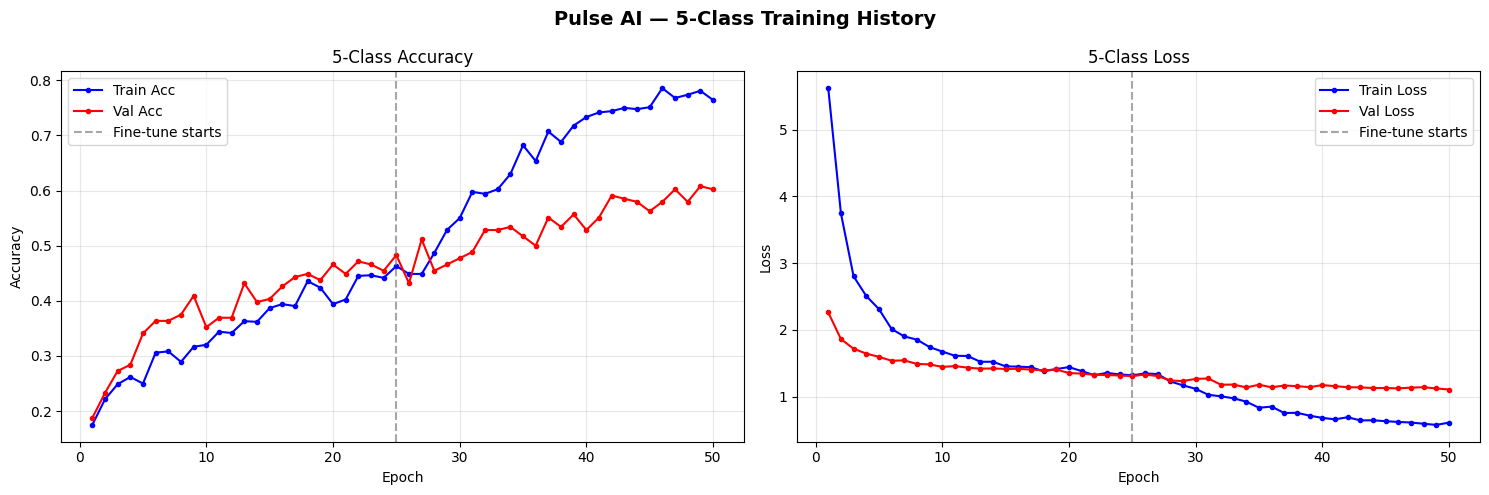

In [18]:
# ── Plot Training History ─────────────────────────────────────────
def merge_histories(h1, h2):
    """Merge Phase 1 and Phase 2 histories"""
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history[key]
    return merged


history = merge_histories(history1, history2)
p1_end = len(history1.history['loss'])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Pulse AI — 5-Class Training History', fontsize=14, fontweight='bold')

epochs = range(1, len(history['loss']) + 1)

axes[0].plot(epochs, history['accuracy'], 'b-o', label='Train Acc', markersize=3)
axes[0].plot(epochs, history['val_accuracy'], 'r-o', label='Val Acc', markersize=3)
axes[0].axvline(x=p1_end, color='gray', linestyle='--', alpha=0.7, label='Fine-tune starts')
axes[0].set_title('5-Class Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['loss'], 'b-o', label='Train Loss', markersize=3)
axes[1].plot(epochs, history['val_loss'], 'r-o', label='Val Loss', markersize=3)
axes[1].axvline(x=p1_end, color='gray', linestyle='--', alpha=0.7, label='Fine-tune starts')
axes[1].set_title('5-Class Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figures/training_history_5class.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
# ── Final Evaluation on Test Set ──────────────────────────────────
from tensorflow.keras.applications.vgg16 import preprocess_input

print("📊 Evaluating on 5-class Test Set...\n")

best_model = keras.models.load_model(MODEL_PATH)
X_test_vgg = preprocess_input(X_test.copy())

test_loss, test_acc, test_auc = best_model.evaluate(X_test_vgg, y_test_cat, verbose=0)
print(f"   Test Loss     : {test_loss:.4f}")
print(f"   Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"   Test AUC      : {test_auc:.4f}")

y_pred_probs = best_model.predict(X_test_vgg, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

y_test_labels = np.array([INT_TO_ACDC[int(label)] for label in y_test])
y_pred_labels = np.array([INT_TO_ACDC[int(label)] for label in y_pred])

y_test_threat = np.array([ACDC_TO_THREAT[label] for label in y_test_labels])
y_pred_threat = np.array([ACDC_TO_THREAT[label] for label in y_pred_labels])
y_test_threat_int = np.array([THREAT_TO_INT[label] for label in y_test_threat])
y_pred_threat_int = np.array([THREAT_TO_INT[label] for label in y_pred_threat])

threat_acc = np.mean(y_test_threat == y_pred_threat)

print("\n📋 5-Class Classification Report:")
print(classification_report(
    y_test,
    y_pred,
    labels=list(range(len(ACDC_CLASSES))),
    target_names=[f"{label} ({ACDC_TO_NAME[label]})" for label in ACDC_CLASSES],
))

print("📋 Threat-Level Report (mapped after inference):")
print(classification_report(
    y_test_threat,
    y_pred_threat,
    labels=THREAT_CLASSES,
    target_names=[f"{label} Risk" for label in THREAT_CLASSES],
))
print(f"✅ Threat-Level Accuracy: {threat_acc*100:.2f}%")

📊 Evaluating on 5-class Test Set...



   Test Loss     : 1.0866
   Test Accuracy : 0.5924 (59.24%)
   Test AUC      : 0.8600

📋 5-Class Classification Report:
                                   precision    recall  f1-score   support

                     NOR (Normal)       0.62      0.38      0.47        40
    RV (Abnormal Right Ventricle)       0.59      0.75      0.66        32
HCM (Hypertrophic Cardiomyopathy)       0.69      0.85      0.76        40
     MINF (Myocardial Infarction)       0.45      0.33      0.38        40
     DCM (Dilated Cardiomyopathy)       0.56      0.72      0.63        32

                         accuracy                           0.59       184
                        macro avg       0.58      0.60      0.58       184
                     weighted avg       0.58      0.59      0.57       184

📋 Threat-Level Report (mapped after inference):
              precision    recall  f1-score   support

    Low Risk       0.62      0.38      0.47        40
 Medium Risk       0.67      0.83      0.74 

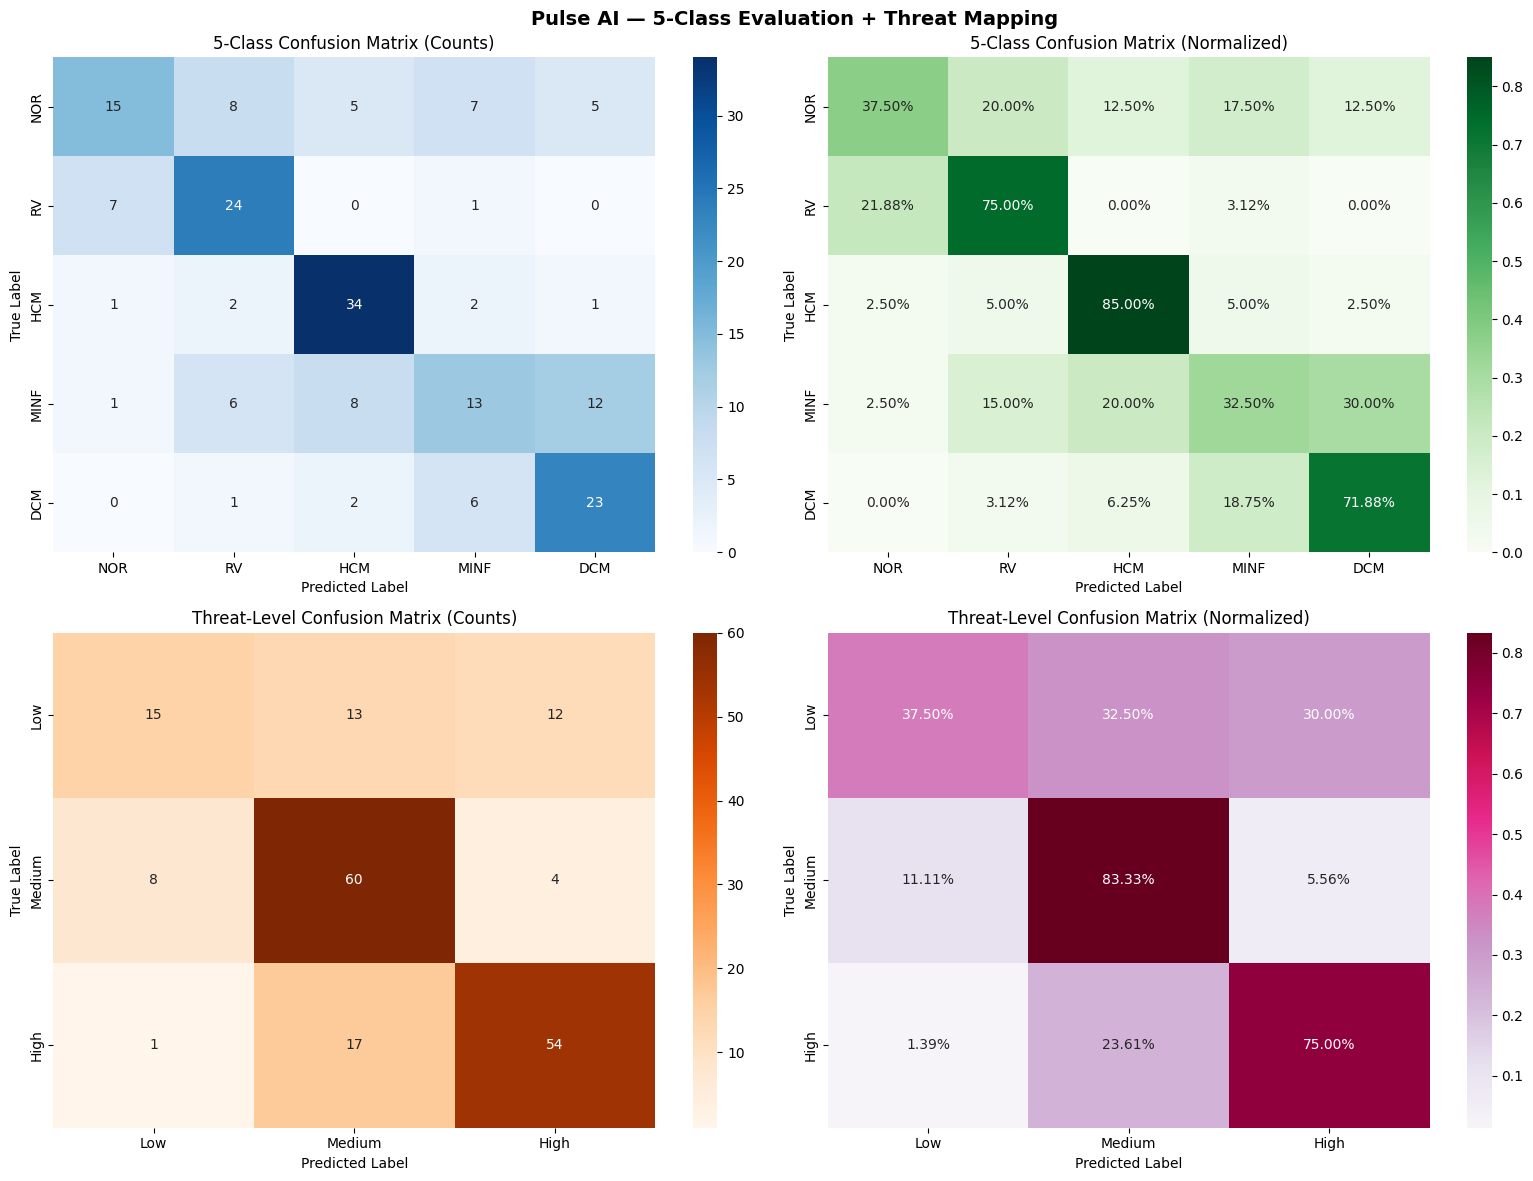


✅ Final 5-Class Accuracy: 59.24%
✅ Final Threat-Level Accuracy: 70.11%


In [20]:
# ── Confusion Matrices: 5-Class and Threat-Level ──────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Pulse AI — 5-Class Evaluation + Threat Mapping', fontsize=14, fontweight='bold')

cm_5class = confusion_matrix(y_test, y_pred, labels=list(range(len(ACDC_CLASSES))))
sns.heatmap(
    cm_5class,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0][0],
    xticklabels=ACDC_CLASSES,
    yticklabels=ACDC_CLASSES,
)
axes[0][0].set_title('5-Class Confusion Matrix (Counts)')
axes[0][0].set_ylabel('True Label')
axes[0][0].set_xlabel('Predicted Label')

cm_5class_norm = cm_5class.astype('float') / cm_5class.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_5class_norm,
    annot=True,
    fmt='.2%',
    cmap='Greens',
    ax=axes[0][1],
    xticklabels=ACDC_CLASSES,
    yticklabels=ACDC_CLASSES,
)
axes[0][1].set_title('5-Class Confusion Matrix (Normalized)')
axes[0][1].set_ylabel('True Label')
axes[0][1].set_xlabel('Predicted Label')

cm_threat = confusion_matrix(y_test_threat_int, y_pred_threat_int, labels=list(range(len(THREAT_CLASSES))))
sns.heatmap(
    cm_threat,
    annot=True,
    fmt='d',
    cmap='Oranges',
    ax=axes[1][0],
    xticklabels=THREAT_CLASSES,
    yticklabels=THREAT_CLASSES,
)
axes[1][0].set_title('Threat-Level Confusion Matrix (Counts)')
axes[1][0].set_ylabel('True Label')
axes[1][0].set_xlabel('Predicted Label')

cm_threat_norm = cm_threat.astype('float') / cm_threat.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_threat_norm,
    annot=True,
    fmt='.2%',
    cmap='PuRd',
    ax=axes[1][1],
    xticklabels=THREAT_CLASSES,
    yticklabels=THREAT_CLASSES,
)
axes[1][1].set_title('Threat-Level Confusion Matrix (Normalized)')
axes[1][1].set_ylabel('True Label')
axes[1][1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('figures/confusion_matrix_5class_and_threat.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Final 5-Class Accuracy: {test_acc*100:.2f}%")
print(f"✅ Final Threat-Level Accuracy: {threat_acc*100:.2f}%")

🩺 Patient-Level Threat Evaluation
   Test patients          : 23
   Patient-level Accuracy : 0.7391 (73.91%)

📋 Patient-Level Threat Report:
              precision    recall  f1-score   support

    Low Risk       0.67      0.40      0.50         5
 Medium Risk       0.67      0.89      0.76         9
   High Risk       0.88      0.78      0.82         9

    accuracy                           0.74        23
   macro avg       0.74      0.69      0.70        23
weighted avg       0.75      0.74      0.73        23



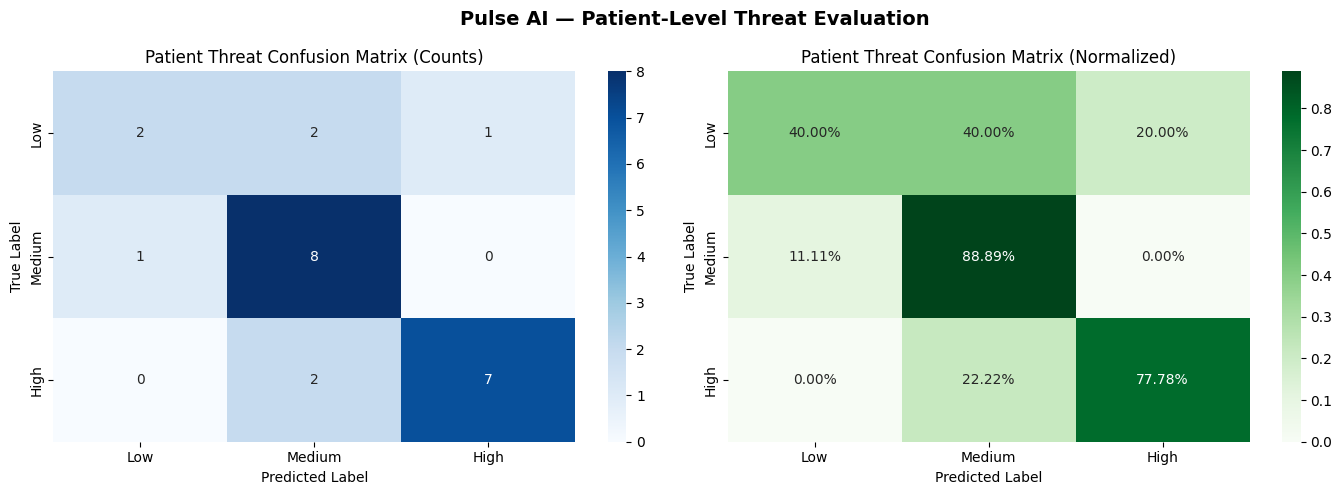

In [21]:
# ── Patient-Level Threat Evaluation (Mapped from 5-Class Predictions) ──
from collections import defaultdict

patient_prob_groups = defaultdict(list)
patient_true_acdc = {}

for patient_id, probs, true_label in zip(test_patient_ids, y_pred_probs, y_test):
    patient_prob_groups[patient_id].append(probs)
    patient_true_acdc[patient_id] = INT_TO_ACDC[int(true_label)]

patient_level_true_acdc = []
patient_level_pred_acdc = []
patient_level_true_threat = []
patient_level_pred_threat = []

for patient_id in sorted(patient_prob_groups):
    avg_probs = np.mean(patient_prob_groups[patient_id], axis=0)
    pred_label_int = int(np.argmax(avg_probs))
    pred_acdc = INT_TO_ACDC[pred_label_int]
    true_acdc = patient_true_acdc[patient_id]

    patient_level_true_acdc.append(true_acdc)
    patient_level_pred_acdc.append(pred_acdc)
    patient_level_true_threat.append(ACDC_TO_THREAT[true_acdc])
    patient_level_pred_threat.append(ACDC_TO_THREAT[pred_acdc])

patient_level_true_threat = np.array(patient_level_true_threat)
patient_level_pred_threat = np.array(patient_level_pred_threat)
patient_level_threat_acc = np.mean(patient_level_true_threat == patient_level_pred_threat)

print("🩺 Patient-Level Threat Evaluation")
print(f"   Test patients          : {len(patient_level_true_threat)}")
print(f"   Patient-level Accuracy : {patient_level_threat_acc:.4f} ({patient_level_threat_acc*100:.2f}%)")
print()
print("📋 Patient-Level Threat Report:")
print(classification_report(
    patient_level_true_threat,
    patient_level_pred_threat,
    labels=THREAT_CLASSES,
    target_names=[f"{label} Risk" for label in THREAT_CLASSES],
))

patient_cm = confusion_matrix(
    [THREAT_TO_INT[label] for label in patient_level_true_threat],
    [THREAT_TO_INT[label] for label in patient_level_pred_threat],
    labels=list(range(len(THREAT_CLASSES))),
)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Pulse AI — Patient-Level Threat Evaluation', fontsize=14, fontweight='bold')

sns.heatmap(patient_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=THREAT_CLASSES,
            yticklabels=THREAT_CLASSES)
axes[0].set_title('Patient Threat Confusion Matrix (Counts)')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

patient_cm_norm = patient_cm.astype('float') / patient_cm.sum(axis=1, keepdims=True)
sns.heatmap(patient_cm_norm, annot=True, fmt='.2%', cmap='Greens', ax=axes[1],
            xticklabels=THREAT_CLASSES,
            yticklabels=THREAT_CLASSES)
axes[1].set_title('Patient Threat Confusion Matrix (Normalized)')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

---
## STEP 9 — Save 5-Class Model & Test Threat Mapping

In [22]:
# ── Save in Multiple Formats ──────────────────────────────────────

best_model.save(MODEL_PATH)
print(f"✅ Saved: {MODEL_PATH}  (use with Flask)")

converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
tflite_model = converter.convert()
with open('models/pulse_ai_model_5class.tflite', 'wb') as f:
    f.write(tflite_model)
print("✅ Saved: pulse_ai_model_5class.tflite (lightweight version)")

print()
h5_size = os.path.getsize(MODEL_PATH) / 1024**2
tflite_size = os.path.getsize('models/pulse_ai_model_5class.tflite') / 1024**2
print(f"📦 Model sizes:")
print(f"   .h5     : {h5_size:.1f} MB")
print(f"   .tflite : {tflite_size:.1f} MB")

✅ Saved: pulse_ai_model_5class.h5  (use with Flask)
INFO:tensorflow:Assets written to: C:\Users\Abdul\AppData\Local\Temp\tmpoflj_xja\assets


INFO:tensorflow:Assets written to: C:\Users\Abdul\AppData\Local\Temp\tmpoflj_xja\assets


Saved artifact at 'C:\Users\Abdul\AppData\Local\Temp\tmpoflj_xja'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  2112574593296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2112574600784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2112574600976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2112574593488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2112574785680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2112574789712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2112574789520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2112574790096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2112574789904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2112574793936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2112

In [23]:
# ── Test Single Image Prediction (5-Class → Threat Mapping) ───────
from tensorflow.keras.applications.vgg16 import preprocess_input

CENTER_CROP_RATIO = globals().get('CENTER_CROP_RATIO', 0.70)


def center_crop_rgb(image, crop_ratio=0.70):
    height, width = image.shape[:2]
    crop_h = max(32, int(height * crop_ratio))
    crop_w = max(32, int(width * crop_ratio))
    y0 = max(0, (height - crop_h) // 2)
    x0 = max(0, (width - crop_w) // 2)
    y1 = min(height, y0 + crop_h)
    x1 = min(width, x0 + crop_w)
    return image[y0:y1, x0:x1]


def map_probs_to_threat(acdc_probs):
    threat_probs = {label: 0.0 for label in THREAT_CLASSES}
    for class_idx, prob in enumerate(acdc_probs):
        acdc_class = INT_TO_ACDC[class_idx]
        threat_label = ACDC_TO_THREAT[acdc_class]
        threat_probs[threat_label] += float(prob)
    return threat_probs


def predict_single_image(img_path, model, img_size=(224, 224)):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = center_crop_rgb(img, crop_ratio=CENTER_CROP_RATIO)
    img = cv2.resize(img, img_size)
    img = img.astype(np.float32)
    model_input = preprocess_input(np.expand_dims(img, axis=0))

    acdc_probs = model.predict(model_input, verbose=0)[0]
    acdc_class = INT_TO_ACDC[int(np.argmax(acdc_probs))]
    threat_probs = map_probs_to_threat(acdc_probs)
    threat_level = max(threat_probs, key=threat_probs.get)

    result = {
        'acdcClass': acdc_class,
        'acdcName': ACDC_TO_NAME[acdc_class],
        'threatLevel': threat_level,
        'confidence': round(float(np.max(acdc_probs)) * 100, 2),
        'acdcProbabilities': {
            INT_TO_ACDC[idx]: round(float(prob) * 100, 2)
            for idx, prob in enumerate(acdc_probs)
        },
        'threatProbabilities': {
            label: round(prob * 100, 2)
            for label, prob in threat_probs.items()
        },
    }
    return result


print("🔬 Testing predictions on sample images:\n")
for acdc_class in ACDC_CLASSES:
    folder = os.path.join(OUTPUT_PATH, acdc_class)
    sample = os.path.join(folder, os.listdir(folder)[0])
    result = predict_single_image(sample, best_model)

    print(f"True ACDC: {acdc_class:4s} ({ACDC_TO_NAME[acdc_class]})")
    print(f"Predicted : {result['acdcClass']:4s} ({result['acdcName']})")
    print(f"Threat    : {result['threatLevel']}  | Confidence: {result['confidence']}%")
    print(f"5-class probabilities: {result['acdcProbabilities']}")
    print(f"Threat probabilities : {result['threatProbabilities']}")
    print()

🔬 Testing predictions on sample images:

True ACDC: NOR  (Normal)
Predicted : HCM  (Hypertrophic Cardiomyopathy)
Threat    : Medium  | Confidence: 38.88%
5-class probabilities: {'NOR': 21.72, 'RV': 13.11, 'HCM': 38.88, 'MINF': 24.37, 'DCM': 1.92}
Threat probabilities : {'Low': 21.72, 'Medium': 52.0, 'High': 26.29}

True ACDC: RV   (Abnormal Right Ventricle)
Predicted : NOR  (Normal)
Threat    : High  | Confidence: 30.8%
5-class probabilities: {'NOR': 30.8, 'RV': 25.06, 'HCM': 6.0, 'MINF': 26.95, 'DCM': 11.18}
Threat probabilities : {'Low': 30.8, 'Medium': 31.07, 'High': 38.13}

True ACDC: HCM  (Hypertrophic Cardiomyopathy)
Predicted : HCM  (Hypertrophic Cardiomyopathy)
Threat    : Medium  | Confidence: 88.13%
5-class probabilities: {'NOR': 3.54, 'RV': 0.12, 'HCM': 88.13, 'MINF': 7.79, 'DCM': 0.42}
Threat probabilities : {'Low': 3.54, 'Medium': 88.25, 'High': 8.2}

True ACDC: MINF (Myocardial Infarction)
Predicted : MINF (Myocardial Infarction)
Threat    : High  | Confidence: 91.58%
5-c

---
## STEP 10 — Flask API Code
 > ⚠ **Do NOT run this in the notebook.** Copy this code into a new file called `app.py` and run it separately with `python app.py`

In [24]:
# ── app.py — Flask API for Pulse AI 5-Class Model ────────────────
# Save this code in a file called app.py and run: python app.py

flask_code = '''
from flask import Flask, request, jsonify
from flask_cors import CORS
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import preprocess_input

app = Flask(__name__)
CORS(app)

MODEL_PATH = "pulse_ai_model_5class.h5"
model = tf.keras.models.load_model(MODEL_PATH)
ACDC_CLASSES = ['NOR', 'RV', 'HCM', 'MINF', 'DCM']
INT_TO_ACDC = {idx: label for idx, label in enumerate(ACDC_CLASSES)}
ACDC_TO_NAME = {
    'NOR': 'Normal',
    'RV': 'Abnormal Right Ventricle',
    'HCM': 'Hypertrophic Cardiomyopathy',
    'MINF': 'Myocardial Infarction',
    'DCM': 'Dilated Cardiomyopathy',
}
ACDC_TO_THREAT = {
    'NOR': 'Low',
    'RV': 'Medium',
    'HCM': 'Medium',
    'MINF': 'High',
    'DCM': 'High',
}
THREAT_CLASSES = ['Low', 'Medium', 'High']
IMAGE_SIZE = (224, 224)
CENTER_CROP_RATIO = 0.70

print(f"✅ Pulse AI VGG16 5-class model loaded from {MODEL_PATH}")


def center_crop_rgb(image, crop_ratio=0.70):
    height, width = image.shape[:2]
    crop_h = max(32, int(height * crop_ratio))
    crop_w = max(32, int(width * crop_ratio))
    y0 = max(0, (height - crop_h) // 2)
    x0 = max(0, (width - crop_w) // 2)
    y1 = min(height, y0 + crop_h)
    x1 = min(width, x0 + crop_w)
    return image[y0:y1, x0:x1]


def preprocess_image(file_bytes):
    img_array = np.frombuffer(file_bytes, np.uint8)
    img = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = center_crop_rgb(img, crop_ratio=CENTER_CROP_RATIO)
    img = cv2.resize(img, IMAGE_SIZE)
    img = img.astype(np.float32)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)
    return img


def map_probs_to_threat(acdc_probs):
    threat_probs = {label: 0.0 for label in THREAT_CLASSES}
    for class_idx, prob in enumerate(acdc_probs):
        acdc_class = INT_TO_ACDC[class_idx]
        threat_probs[ACDC_TO_THREAT[acdc_class]] += float(prob)
    return threat_probs


@app.route("/health", methods=["GET"])
def health_check():
    return jsonify({"status": "Pulse AI VGG16 5-class Flask API is running"})


@app.route("/analyze", methods=["POST"])
def analyze_mri():
    if "mri_image" not in request.files:
        return jsonify({"error": "No file uploaded"}), 400

    file = request.files["mri_image"]
    file_bytes = file.read()

    try:
        img = preprocess_image(file_bytes)
        acdc_probs = model.predict(img, verbose=0)[0]
        acdc_class = INT_TO_ACDC[int(np.argmax(acdc_probs))]
        threat_probs = map_probs_to_threat(acdc_probs)
        threat_level = max(threat_probs, key=threat_probs.get)
        confidence = round(float(np.max(acdc_probs)) * 100, 2)

        return jsonify({
            "acdcClass": acdc_class,
            "acdcName": ACDC_TO_NAME[acdc_class],
            "threatLevel": threat_level,
            "confidence": confidence,
            "acdcProbabilities": {
                INT_TO_ACDC[idx]: round(float(prob) * 100, 2)
                for idx, prob in enumerate(acdc_probs)
            },
            "threatProbabilities": {
                label: round(prob * 100, 2)
                for label, prob in threat_probs.items()
            },
            "recommendation": get_recommendation(threat_level)
        })
    except Exception as e:
        return jsonify({"error": str(e)}), 500


def get_recommendation(threat_level):
    recommendations = {
        "Low": "No immediate concern. Routine annual checkup recommended.",
        "Medium": "Consult a cardiologist within 2-4 weeks for further evaluation.",
        "High": "Urgent cardiologist consultation required. Schedule within 48-72 hours."
    }
    return recommendations.get(threat_level, "Please consult a doctor.")


if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000, debug=False)
'''

with open('scripts/app_5class.py', 'w', encoding='utf-8') as f:
    f.write(flask_code.strip())

print("✅ app_5class.py created!")
print()
print("To run the Flask API:")
print("  pip install flask flask-cors")
print("  python scripts/app_5class.py")
print()
print("API Endpoints:")
print("  GET  http://localhost:5000/health")
print("  POST http://localhost:5000/analyze   ← send MRI image here")

✅ app_5class.py created!

To run the Flask API:
  pip install flask flask-cors
  python scripts/app_5class.py

API Endpoints:
  GET  http://localhost:5000/health
  POST http://localhost:5000/analyze   ← send MRI image here


In [25]:
# ── Node.js Integration Code (Save as analyzeService5Class.js) ────
nodejs_code = '''
// analyzeService5Class.js — Call Pulse AI Flask 5-class API from Node.js/Express
const axios = require('axios');
const FormData = require('form-data');

const FLASK_URL = process.env.FLASK_URL || 'http://localhost:5000';

async function analyzeMRI(fileBuffer, originalFilename) {
    const formData = new FormData();
    formData.append('mri_image', fileBuffer, {
        filename: originalFilename,
        contentType: 'image/png'
    });

    const response = await axios.post(`${FLASK_URL}/analyze`, formData, {
        headers: formData.getHeaders(),
        timeout: 30000
    });

    return response.data;
    /*
    Returns:
    {
        acdcClass: "MINF",
        acdcName: "Myocardial Infarction",
        threatLevel: "High",
        confidence: 87.45,
        acdcProbabilities: { NOR: 1.2, RV: 4.5, HCM: 6.1, MINF: 87.45, DCM: 0.75 },
        threatProbabilities: { Low: 1.2, Medium: 10.6, High: 88.2 },
        recommendation: "Urgent cardiologist consultation required..."
    }
    */
}

module.exports = { analyzeMRI };
'''

with open('scripts/analyzeService5Class.js', 'w') as f:
    f.write(nodejs_code.strip())

print("✅ analyzeService5Class.js created!")
print("   Copy this file to your Node.js backend folder.")

✅ analyzeService5Class.js created!
   Copy this file to your Node.js backend folder.


---
## ✅ Summary — What You Now Have

| File | Purpose |
|---|---|
| `pulse_ai_model_5class.h5` | Trained 5-class VGG16 model for Flask API |
| `pulse_ai_model_5class.tflite` | Lightweight 5-class model for deployment |
| `app_5class.py` | Flask REST API returning both ACDC class and threat level |
| `analyzeService5Class.js` | Node.js service to call the 5-class Flask API |
| `pulse_ai_dataset_5class/` | ROI-cropped PNG images for export, inspection, and sample prediction |
| `confusion_matrix_5class_and_threat.png` | 5-class and mapped threat evaluation chart |
| `training_history_5class.png` | Training curves |

---

## 🏗️ Full System Flow
```
Patient uploads MRI (React)
        ↓
Node.js/Express backend receives file
        ↓
analyzeService5Class.js → POST to Flask
        ↓
Flask preprocess → VGG16 5-class model
        ↓
Predicts one of: NOR / RV / HCM / MINF / DCM
        ↓
Maps prediction to Low / Medium / High threat
        ↓
Node.js saves both original class and mapped threat to Supabase DB
        ↓
Patient sees the threat result on dashboard
```

---
**Author:** Abdul Moiz | F22BDOCS1M01076 | Pulse AI FYP